# 01 · EDA del presupuesto por alumno

Datos externos de gasto, personal y renta para relacionar el presupuesto por alumno con los resultados PISA, **antes de modelar**. Este notebook recopila y explora los datos; las tablas de PISA son las tablas maestras de `00_pipeline_multiedicion_PISA.ipynb`.

El análisis principal usa **solo variables económicas** (gasto, financiación, composición del gasto, salarios, dotación de personal y renta). Las variables que no son económicas (segregación, autonomía, tiempo de aprendizaje, equidad de recursos, perfil del profesorado...) están en una **tabla aparte de contexto educativo** y se describen en el anexo.

## Fuentes

Descargadas el **2026-10-03** con `src/datos_externos.py` (APIs públicas, sin clave) a `data/raw/externos/`, para los 33 países OCDE de las tablas maestras. *Se irán añadiendo aquí las fuentes que se incorporen.* Cada serie enlaza a la página donde se ven los datos (en la OCDE, el *Data Explorer*) y la sección **Enlaces de las fuentes** comprueba, al ejecutarla, que portal y API responden.

Las series de la OCDE son del proyecto *Education at a Glance* (UOE) y siguen la clasificación ISCED 2011: `ISCED11_1` primaria, `_2` secundaria 1.ª etapa, `_3` secundaria 2.ª etapa, `_2_3` ambas, `_1T4` primaria a postsecundaria no terciaria.

### Variables económicas

| Datos | Proveedor y serie | Versión y filtros | Unidades | Fichero local |
|---|---|---|---|---|
| **Gasto por alumno** en instituciones educativas | OCDE: [`DF_UOE_INDIC_FIN_PERSTUD`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_FIN%40DF_UOE_INDIC_FIN_PERSTUD&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=3.2) | v3.2. Todas las fuentes (`_T`), todas las instituciones (`INST_EDU`), gasto total en instituciones (`DIR_EXP`), 2000-2024 | USD PPP por alumno (precios constantes, base 2020, y corrientes); moneda nacional; % del PIB per cápita | `gasto_por_alumno.csv` |
| **Gasto por alumno según el tipo de gasto** (servicios básicos de enseñanza `CORE` y auxiliares `ASERV`: transporte, comidas, alojamiento) | OCDE: [`DF_UOE_INDIC_FIN_PERSTUD`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_FIN%40DF_UOE_INDIC_FIN_PERSTUD&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=3.2) | v3.2. Niveles 1, 2, 3 y 2_3; `INST_EDU`; precios constantes | USD PPP por alumno | `gasto_alumno_tipo.csv` |
| **Gasto como % del PIB y por fuente** (gobierno, privado, exterior) | OCDE: [`DF_UOE_FIN_SOURCE_GV_PR_NDOM`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_FIN%40DF_UOE_FIN_SOURCE_GV_PR_NDOM&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=3.2) | v3.2. Niveles 1, 2, 3, 2_3 y 1T4; todas las fuentes; `INST_EDU`; `DIR_EXP` | % del PIB; % del gasto; USD PPP; moneda nacional | `gasto_pib_y_fuentes.csv` |
| **% del gasto público total dedicado a educación** | OCDE: [`DF_UOE_FIN_INDIC_SHARE_EDU_GOV`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_FIN%40DF_UOE_FIN_INDIC_SHARE_EDU_GOV&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=3.2) | v3.2. Niveles 1, 2, 3, 2_3, 1T4 y 1T8 | % del gasto público total | `gasto_pct_gasto_publico.csv` |
| **Gasto en personal** (remuneración) | OCDE: [`DF_UOE_FIN_NATURE_STAFF`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_FIN%40DF_UOE_FIN_NATURE_STAFF&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=3.2) | v3.2. Niveles 1, 2, 3 y 2_3; `INST_EDU`; todos los tipos de remuneración | USD PPP, precios constantes | `gasto_personal.csv` |
| **Gasto corriente y de capital** | OCDE: [`DF_UOE_FIN_NATURE_CUR_CAP`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_FIN%40DF_UOE_FIN_NATURE_CUR_CAP&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=3.2) | v3.2. Mismos filtros que el de personal | USD PPP, precios constantes | `gasto_corriente_capital.csv` |
| **Matrícula** ajustada al año financiero | OCDE: [`DF_UOE_FIN_ENR`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_FIN_ENR%40DF_UOE_FIN_ENR&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=3.2) | v3.2. Niveles 1, 2, 3 y 2_3; equivalente a tiempo completo (`FTE`); `INST_EDU` | Personas | `matricula_equivalente_tc.csv` |
| **Estadísticas de referencia** (PIB, PIB per cápita, factor PPP, deflactor, población, gasto público total) | OCDE: [`DF_UOE_FIN_ANNEX`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_FIN_ANNEX%40DF_UOE_FIN_ANNEX&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=3.2) | v3.2. Sin filtros | Varias (USD PPP, moneda nacional, índice, personas) | `estadisticas_referencia.csv` |
| **PIB per cápita** | Banco Mundial, WDI: [`NY.GDP.PCAP.PP.KD`](https://data.worldbank.org/indicator/NY.GDP.PCAP.PP.KD) | API v2, 2000-2023 | USD internacionales constantes de 2021 (PPP) | `pib_per_capita_ppp.csv` |
| **Gasto público por alumno** (relleno de huecos) | Eurostat: [`educ_uoe_fine09`](https://ec.europa.eu/eurostat/databrowser/view/educ_uoe_fine09/default/table?lang=en) | Solo países de la UE de los 33, 2010-2023, **solo gasto público** | EUR, PPS, moneda nacional, % del PIB per cápita | `gasto_publico_por_alumno_eurostat.csv` |
| **Salarios reales de los docentes** (media) | OCDE: [`DSD_EAG_SAL_TREND@DF_TCH_ACT`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_SAL_TREND%40DF_TCH_ACT&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=2.1) | v2.1, 2000-2025, profesorado de instituciones públicas de 25 a 64 años | Índice (base 2015 = 100, términos reales) y moneda nacional a precios corrientes. **No hay USD PPP** | `salarios_reales_docentes.csv` |
| **Salarios legales de los docentes** | OCDE: [`DSD_EAG_SAL_TREND@DF_TCH_STA`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_SAL_TREND%40DF_TCH_STA&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=2.1) | v2.1, 2000-2025, salario típico con 0 y 15 años de experiencia | Índice (base 2015 = 100) y moneda nacional a precios corrientes | `salarios_legales_docentes.csv` |
| **Alumnos por docente** (dotación de personal, parte "cantidad" del coste por alumno) | OCDE: [`DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_NF_PERS_STR`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_NON_FIN_PERS%40DF_UOE_NF_PERS_STR&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=1.1) | v1.1, 2013-2024, por nivel y tipo de institución | Alumnos por docente (`ST_TCHR`) | `alumnos_por_docente.csv` |

De PISA, en la parte económica: el **origen de la financiación del centro** (`SC02Q01-04` en 2012; `SC016Q01-04TA` después), los resultados (`PV`) y la media de `ESCS_TREND` como control social.

Acceso a las series de la OCDE: [API SDMX](https://www.oecd.org/en/data/insights/data-explainers/2024/09/api.html) (la página abre en el navegador, pero rechaza peticiones automáticas) (`https://sdmx.oecd.org/public/rest/data/OECD.EDU.IMEP,<dataflow>,<versión>/<clave>`); catálogo de dataflows en [`sdmx.oecd.org/public/rest/dataflow/OECD.EDU.IMEP`](https://sdmx.oecd.org/public/rest/dataflow/OECD.EDU.IMEP). La clave lleva una posición por dimensión del DSD de cada dataflow.

### Contexto educativo (no económico, anexo)

| Datos | Proveedor y serie | Versión y filtros | Unidades | Fichero local |
|---|---|---|---|---|
| **Tamaño de clase** | OCDE: [`DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_NF_PERS_CLS`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_NON_FIN_PERS%40DF_UOE_NF_PERS_CLS&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=1.1) | v1.1, 2013-2024, primaria y secundaria 1.ª etapa | Alumnos por clase (`ST_CL`) | `tamaño_de_clase.csv` |
| **Horas anuales de docencia** (legales) | OCDE: [`DSD_EAG_WT_TREND@DF_ALL`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_WT_TREND%40DF_ALL&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=2.0) | v2.0, 2000-2025, instituciones públicas | Horas por año | `horas_docencia_legales.csv` |
| **Edad del profesorado** | OCDE: [`DSD_EAG_UOE_NON_FIN_PERS@DF_UOE_NF_PERS_AGE`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_NON_FIN_PERS%40DF_UOE_NF_PERS_AGE&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=1.1) | v1.1, secundaria 1.ª etapa, ambos sexos, tramos "50 o más" y "menos de 30", desde 2013 | % del profesorado | `docentes_edad.csv` |
| **Escolarización por edad** | OCDE: [`DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_NF_ENRL_RATE`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_NON_FIN_STUD%40DF_UOE_NF_ENRL_RATE&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=1.1) | v1.1, edades 3, 4, 5 y 15, todos los niveles, desde 2013 | % de la población de esa edad | `escolarizacion_por_edad.csv` |
| **Repetición de curso** | OCDE: [`DSD_EAG_UOE_NON_FIN_STUD@DF_UOE_NF_DIST_RPTR`](https://data-explorer.oecd.org/vis?df%5Bds%5D=DisseminateFinalDMZ&df%5Bid%5D=DSD_EAG_UOE_NON_FIN_STUD%40DF_UOE_NF_DIST_RPTR&df%5Bag%5D=OECD.EDU.IMEP&df%5Bvs%5D=1.1) | v1.1, primaria, sec. 1.ª y 2.ª etapa, desde 2013 | % de repetidores | `repeticion.csv` |

De PISA, en el anexo: tiempo de aprendizaje por asignatura (`MMINS`, `LMINS`, `SMINS`; 2012-2018); recursos del centro (`STRATIO`, `CLSIZE`, `SCHSIZE`, `EDUSHORT`, `STAFFSHORT`, profesorado certificado `PROPCERT`/`PROATCE`, con máster `PROPAT7` solo en 2022, ordenadores por alumno `RATCMP*`); autonomía sobre recursos (`RESPRES` en 2012 y 2015, `SRESPRES` en 2022; **falta en 2018** y la escala no es comparable entre ediciones); y la segregación social entre centros y las brechas de recursos, calculadas con `ESCS_TREND`.

**Consultadas y descartadas**: UNESCO UIS (gasto *público* por alumno, 21 a 29 países; solo llena Bélgica en 2012), Banco Mundial `SE.XPD.*` (acaba en 2016) y los datos de horas de instrucción del alumno, tiempo de docencia real y salarios relativos a los titulados (solo 2017-2025).

## 0. Configuración

In [1]:
import sys, os
sys.path.append(os.path.abspath('../../'))   # para importar `src`

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.datos_externos import descargar_todo, cargar_oecd, comprobar_fuentes
from src.presupuesto_pais_edicion import SELECCION, serie_anual_presupuesto, construir_tabla, dividir_tabla, inventario_variables, residuo_ols, agrupar_perfiles
from src.pisa_pipeline import PAISES_OCDE_TODAS_LAS_EDICIONES

RUTA_EXTERNOS = '../../data/raw/externos'
RUTA_INTERMEDIOS = '../../data/intermediate'
EDICIONES = [2012, 2015, 2018, 2022]
PAISES = PAISES_OCDE_TODAS_LAS_EDICIONES

# Descarga lo que falte (salta los ficheros que ya existen)
rutas = descargar_todo(RUTA_EXTERNOS)
rutas

{'gasto_por_alumno': '../../data/raw/externos\\gasto_por_alumno.csv',
 'salarios_reales_docentes': '../../data/raw/externos\\salarios_reales_docentes.csv',
 'salarios_legales_docentes': '../../data/raw/externos\\salarios_legales_docentes.csv',
 'gasto_pib_y_fuentes': '../../data/raw/externos\\gasto_pib_y_fuentes.csv',
 'gasto_pct_gasto_publico': '../../data/raw/externos\\gasto_pct_gasto_publico.csv',
 'gasto_personal': '../../data/raw/externos\\gasto_personal.csv',
 'gasto_corriente_capital': '../../data/raw/externos\\gasto_corriente_capital.csv',
 'matricula_equivalente_tc': '../../data/raw/externos\\matricula_equivalente_tc.csv',
 'estadisticas_referencia': '../../data/raw/externos\\estadisticas_referencia.csv',
 'horas_docencia_legales': '../../data/raw/externos\\horas_docencia_legales.csv',
 'gasto_alumno_tipo': '../../data/raw/externos\\gasto_alumno_tipo.csv',
 'docentes_edad': '../../data/raw/externos\\docentes_edad.csv',
 'repeticion': '../../data/raw/externos\\repeticion.csv',


### Enlaces de las fuentes

Una fila por fichero descargado. **portal**: dónde ver los datos; **API**: consulta de muestra (España) con el mismo formato que la descarga. Al ejecutar se comprueba cada enlace: en la OCDE, que el dataflow y su versión existen en su catálogo (la web del *Data Explorer* siempre responde 200, aunque el identificador sea incorrecto) y, con `COMPROBAR_API = True`, que la API devuelve datos; en el Banco Mundial y Eurostat, que ambos responden. Necesita conexión.

In [2]:
from IPython.display import HTML

COMPROBAR_API = False   # True pide una muestra a cada API (la OCDE limita las consultas por hora)
enlaces = comprobar_fuentes(api=COMPROBAR_API)
vista = enlaces.assign(portal=[f'<a href="{u}" target="_blank">portal</a>' for u in enlaces['portal']],
                       api=[f'<a href="{u}" target="_blank">API</a>' for u in enlaces['api']])
HTML(vista.drop(columns='formato').to_html(escape=False, index=False))

serie,fichero,proveedor,dataflow,version,portal,api,portal_ok,api_ok
gasto_por_alumno,gasto_por_alumno.csv,OCDE,DSD_EAG_UOE_FIN@DF_UOE_INDIC_FIN_PERSTUD,3.2,portal,API,ok,sin comprobar
salarios_reales_docentes,salarios_reales_docentes.csv,OCDE,DSD_EAG_SAL_TREND@DF_TCH_ACT,2.1,portal,API,ok,sin comprobar
salarios_legales_docentes,salarios_legales_docentes.csv,OCDE,DSD_EAG_SAL_TREND@DF_TCH_STA,2.1,portal,API,ok,sin comprobar
gasto_pib_y_fuentes,gasto_pib_y_fuentes.csv,OCDE,DSD_EAG_UOE_FIN@DF_UOE_FIN_SOURCE_GV_PR_NDOM,3.2,portal,API,ok,sin comprobar
gasto_pct_gasto_publico,gasto_pct_gasto_publico.csv,OCDE,DSD_EAG_UOE_FIN@DF_UOE_FIN_INDIC_SHARE_EDU_GOV,3.2,portal,API,ok,sin comprobar
gasto_personal,gasto_personal.csv,OCDE,DSD_EAG_UOE_FIN@DF_UOE_FIN_NATURE_STAFF,3.2,portal,API,ok,sin comprobar
gasto_corriente_capital,gasto_corriente_capital.csv,OCDE,DSD_EAG_UOE_FIN@DF_UOE_FIN_NATURE_CUR_CAP,3.2,portal,API,ok,sin comprobar
matricula_equivalente_tc,matricula_equivalente_tc.csv,OCDE,DSD_EAG_UOE_FIN_ENR@DF_UOE_FIN_ENR,3.2,portal,API,ok,sin comprobar
estadisticas_referencia,estadisticas_referencia.csv,OCDE,DSD_EAG_UOE_FIN_ANNEX@DF_UOE_FIN_ANNEX,3.2,portal,API,ok,sin comprobar
horas_docencia_legales,horas_docencia_legales.csv,OCDE,DSD_EAG_WT_TREND@DF_ALL,2.0,portal,API,ok,sin comprobar


In [3]:
fallos = enlaces[(enlaces['portal_ok'] != 'ok') | enlaces['api_ok'].str.startswith(('ERROR', 'sin datos', 'límite'))]
print(f'{len(enlaces) - len(fallos)} de {len(enlaces)} fuentes sin fallos (portal{" y API" if COMPROBAR_API else ""} comprobados)')
fallos[['serie', 'portal_ok', 'api_ok']]

18 de 18 fuentes sin fallos (portal comprobados)


,serie,portal_ok,api_ok


## 1. Carga y cobertura

Se unifican los nombres de columna (`pais`, `año`, `valor`, `nivel`...) y se mide cuántos de los 33 países tienen dato en cada edición PISA. Las series marcadas con *(contexto)* no son económicas y van al anexo.

In [4]:
def cargar(nombre):
    """CSV de la OCDE -> `pais`, `año`, `valor` y sus dimensiones (ver `cargar_oecd`)."""
    return cargar_oecd(rutas[nombre])


gasto = cargar('gasto_por_alumno')
gasto_pib = cargar('gasto_pib_y_fuentes')
gasto_pct_publico = cargar('gasto_pct_gasto_publico')
gasto_personal = cargar('gasto_personal')
gasto_corriente_capital = cargar('gasto_corriente_capital')
matricula = cargar('matricula_equivalente_tc')
referencia = cargar('estadisticas_referencia')
salarios_reales = cargar('salarios_reales_docentes')
salarios_legales = cargar('salarios_legales_docentes')
alumnos_docente = cargar('alumnos_por_docente')
horas_docencia = cargar('horas_docencia_legales')
tamaño_clase = cargar('tamaño_de_clase')
pib = pd.read_csv(rutas['pib_per_capita_ppp']).dropna(subset=['valor'])
eurostat = pd.read_csv(rutas['gasto_publico_por_alumno_eurostat'])


def paises_con_dato(df, **filtros):
    """Nº de países con dato en cada edición PISA, aplicando `filtros` (columna=valor)."""
    for k, v in filtros.items():
        df = df[df[k] == v]
    return df[df['año'].isin(EDICIONES)].groupby('año')['pais'].nunique().reindex(EDICIONES).fillna(0).astype(int)

In [5]:
cobertura = pd.DataFrame({
    'gasto por alumno · primaria (USD PPP, const.)': paises_con_dato(gasto, nivel='ISCED11_1', unidad='USD_PPP_ST', precios='Q'),
    'gasto por alumno · secundaria 1.ª etapa': paises_con_dato(gasto, nivel='ISCED11_2', unidad='USD_PPP_ST', precios='Q'),
    'gasto por alumno · secundaria 2.ª etapa': paises_con_dato(gasto, nivel='ISCED11_3', unidad='USD_PPP_ST', precios='Q'),
    'gasto por alumno · secundaria 1.ª+2.ª': paises_con_dato(gasto, nivel='ISCED11_2_3', unidad='USD_PPP_ST', precios='Q'),
    'gasto por alumno público (Eurostat) · sec. 1.ª etapa (PPS)': paises_con_dato(eurostat.assign(institucion=0), nivel='ED2', unidad='PPS'),
    'gasto % del PIB · sec. 1.ª+2.ª (todas las fuentes)': paises_con_dato(gasto_pib, nivel='ISCED11_2_3', unidad='PT_B1GQ', fuente='_T'),
    '% del gasto público total · sec. 1.ª+2.ª': paises_con_dato(gasto_pct_publico, nivel='ISCED11_2_3'),
    'gasto en personal · sec. 1.ª+2.ª': paises_con_dato(gasto_personal, nivel='ISCED11_2_3'),
    'gasto corriente y capital · sec. 1.ª+2.ª': paises_con_dato(gasto_corriente_capital, nivel='ISCED11_2_3'),
    'matrícula (FTE) · sec. 1.ª+2.ª': paises_con_dato(matricula, nivel='ISCED11_2_3'),
    'estadísticas de referencia (PIB per cápita PPP)': paises_con_dato(referencia, medida='GDP_CAPITA'),
    'PIB per cápita PPP (Banco Mundial)': pib[pib['año'].isin(EDICIONES)].groupby('año')['pais'].nunique().reindex(EDICIONES),
    'salario real docente · sec. 1.ª etapa (índice)': paises_con_dato(salarios_reales, nivel='ISCED11_24', unidad='IX'),
    'salario legal docente · sec. 1.ª etapa (índice)': paises_con_dato(salarios_legales, nivel='ISCED11_24', unidad='IX'),
    'alumnos por docente · sec. 1.ª etapa (todas)': paises_con_dato(alumnos_docente, nivel='ISCED11_2', institucion='INST_EDU'),
    '(contexto) horas anuales de docencia (legales) · sec. 1.ª': paises_con_dato(horas_docencia, nivel='ISCED11_24'),
    '(contexto) tamaño de clase · sec. 1.ª etapa (todas)': paises_con_dato(tamaño_clase, nivel='ISCED11_2', institucion='INST_EDU'),
}).T
cobertura.columns = EDICIONES
print(f'Países con dato en cada edición PISA (de {len(PAISES)}; Eurostat solo cubre los de la UE):')
cobertura

Países con dato en cada edición PISA (de 33; Eurostat solo cubre los de la UE):


,2012,2015,2018,2022
"gasto por alumno · primaria (USD PPP, const.)",29,31,31,32
gasto por alumno · secundaria 1.ª etapa,27,29,29,30
gasto por alumno · secundaria 2.ª etapa,29,32,32,33
gasto por alumno · secundaria 1.ª+2.ª,28,30,32,32
gasto por alumno público (Eurostat) · sec. 1.ª etapa (PPS),17,17,19,19
gasto % del PIB · sec. 1.ª+2.ª (todas las fuentes),28,30,32,32
% del gasto público total · sec. 1.ª+2.ª,28,31,32,32
gasto en personal · sec. 1.ª+2.ª,22,26,28,28
gasto corriente y capital · sec. 1.ª+2.ª,24,26,29,30
matrícula (FTE) · sec. 1.ª+2.ª,29,30,32,31


### Notas sobre la cobertura

* **Gasto por alumno**: hay huecos en 2012 en secundaria (entre otros Australia, Bélgica, Canadá, Corea y Países Bajos), y son de toda la recogida de gasto de la OCDE, también del % del PIB. Canadá e Israel no tienen secundaria 1.ª etapa en ningún año. El gasto *acumulado* de los 6 a los 15 años solo es calculable para unos pocos países en 2012 y 2015.
* **Eurostat**: rellena solo **Países Bajos** en 2012 (Bélgica no figura). Es gasto público en PPS: en los países con ambos datos equivale a ~66% (entre 57% y 73%) del gasto total de la OCDE en USD PPP, por lo que sirve como proxy y no como valor directo; habría que reescalarlo.
* **Salarios**: la serie histórica no trae USD PPP; para comparar niveles entre países se puede convertir con el factor PPP de `estadisticas_referencia` o dividir por el PIB per cápita. El índice (base 2015 = 100) sirve para la evolución dentro de cada país.
* **Alumnos por docente** (y tamaño de clase): empiezan en 2013, así que no cubren PISA 2012. Las horas de docencia no llegan a 2022.

## 2. Tabla económica país-edición

Una fila por **país y edición PISA** (33 × 4 = 132 filas) con los resultados de PISA, la media de `ESCS_TREND` como control social y las variables **económicas**. Se construye con `src/presupuesto_pais_edicion.py` y se divide en dos (`dividir_tabla`) para el análisis:

* **Económica** (`economica`): esta sección y las siguientes.
* **Contexto educativo** (`contexto`, no económico): anexo. La lista de qué es contexto está en `CONTEXTO_EDUCATIVO` del módulo.

De todas las variables se guarda en **un único parquet** (`data/intermediate/presupuesto_pais_edicion.parquet`) la **selección** de la sección 2.3: variables **básicas** de fuentes externas, en unidades comparables, para hacer después feature engineering. Es pequeño y se versiona en git; el resto de tablas se regeneran con este notebook.

**Convenciones**
* Las variables externas son del **año de la edición** (2012, 2015, 2018, 2022).
* **No se imputa nada**: los huecos son NaN. Solo se interpolan linealmente los huecos *interiores* de una serie anual para calcular `gasto_alumno_2_3_media_4a` y `gasto_acumulado_6_15`.
* **Unidades comparables**: todo importe está en **USD PPP a precios constantes de 2020** (el de la OCDE para el gasto por alumno); los salarios y el PIB per cápita, que vienen en moneda nacional, se convierten con el método de la sección 2.3. Las demás variables son % o recuentos.
* **Gasto por alumno**: USD PPP a precios constantes (base 2020), todas las fuentes de financiación. Se dan los niveles por separado (`_1` primaria, `_2` secundaria 1.ª etapa, `_3` secundaria 2.ª etapa) y combinados (`_2_3`).
* `gasto_alumno_2_3_media_4a`: media de los 4 años hasta la edición (t-3 a t), si hay al menos 3.
* `gasto_acumulado_6_15`: aproximación al gasto acumulado de los 6 a los 15 años: 6 años de primaria (t-9 a t-4) y 4 de secundaria 1.ª etapa (t-3 a t). Es NaN si falta algún año; no usa la duración teórica de cada país.
* **PISA**: medias por país ponderadas con `W_FSTUWT` (alumnos) y `W_SCHGRNRABWT` (centros). `ESCS` es `ESCS_TREND`.
* Los **ceros que en realidad son datos no disponibles** (p. ej. gasto no docente en Dinamarca y Hungría, gasto en preprimaria de México en 2012) se pasan a NaN.
* Eurostat es solo gasto público en PPS, **no se mezcla** con el de la OCDE: va en columnas aparte, para decidir después cómo usarlo como relleno.

In [6]:
tabla = construir_tabla(RUTA_INTERMEDIOS, RUTA_EXTERNOS)
economica, contexto = dividir_tabla(tabla)

# Único parquet: variables básicas de la selección (sección 2.3), solo fuentes externas
seleccion = tabla[['pais', 'edicion'] + SELECCION]
ruta_seleccion = os.path.join(RUTA_INTERMEDIOS, 'presupuesto_pais_edicion.parquet')
seleccion.to_parquet(ruta_seleccion, index=False)
print(f'selección: {seleccion.shape[0]} filas x {seleccion.shape[1]} columnas -> {ruta_seleccion}')
economica.head()

selección: 132 filas x 25 columnas -> ../../data/intermediate\presupuesto_pais_edicion.parquet


,pais,edicion,pisa_math,pisa_read,pisa_scie,pisa_n_alumnos,pisa_escs_trend_media,pisa_fin_gobierno_pct,pisa_fin_cuotas_pct,pisa_fin_donaciones_pct,...,salario_legal_15a_pct_pib_pc,salario_legal_15a_usd_ppp,salario_real_indice_2015,alumnos_por_docente_sec1,docentes_por_100_alumnos,coste_docentes_por_alumno_pct_pib_pc,salario_legal_15a_por_1000h,eurostat_gasto_publico_alumno_sec1_pps,eurostat_gasto_publico_alumno_sec2_pps,pib_pc_ppp_const2021
0,AUS,2012,504.150766,511.803998,521.494746,14481,0.141659,73.554667,23.210746,1.858552,...,121.313766,65261.671033,104.015117,NaN,NaN,NaN,149.955211,NaN,NaN,54403.883690
1,AUS,2015,493.896231,502.900560,509.993854,14530,0.204237,75.219766,22.446979,1.881341,...,132.843858,73637.838821,100.000000,NaN,NaN,NaN,164.818683,NaN,NaN,55879.995882
2,AUS,2018,491.360025,502.631724,502.964563,14273,0.214675,74.544824,22.500446,1.989934,...,127.972630,71527.288856,NaN,NaN,NaN,NaN,157.796091,NaN,NaN,57647.845507
3,AUS,2022,487.084254,498.050940,507.000869,13437,0.379367,75.912988,22.282262,1.216286,...,114.681470,66314.862663,106.164143,NaN,NaN,NaN,NaN,NaN,NaN,60029.132919
4,AUT,2012,505.540743,489.609335,505.781247,4755,-0.125314,NaN,NaN,NaN,...,105.792903,63070.910607,NaN,NaN,NaN,NaN,174.288144,10473.2,11000.8,61376.634593


### 2.1 Cobertura por variable y edición

Nº de países (de 33) con dato. Los huecos de 2012 son los de la recogida de gasto de la OCDE; los alumnos por docente no existen antes de 2013.

In [7]:
pd.set_option('display.max_rows', 100)
economica.drop(columns=['pais']).groupby('edicion').count().T

edicion,2012,2015,2018,2022
pisa_math,33,33,33,33
pisa_read,33,33,33,33
pisa_scie,33,33,33,33
pisa_n_alumnos,33,33,33,33
pisa_escs_trend_media,33,33,33,33
pisa_fin_gobierno_pct,31,30,28,29
pisa_fin_cuotas_pct,31,30,28,29
pisa_fin_donaciones_pct,31,30,28,29
pisa_fin_otras_pct,31,30,28,29
gasto_alumno_1,29,31,31,32


### 2.2 Diccionario de variables económicas

**Resultados de PISA y control social** (tablas maestras)

| Variable | Descripción | Unidad |
|---|---|---|
| `pais`, `edicion` | País (ISO3) y año de la edición | |
| `pisa_math`, `pisa_read`, `pisa_scie` | Rendimiento medio del país por dominio (PV promediados, ponderados con `W_FSTUWT`) | puntos |
| `pisa_n_alumnos` | Alumnos de la muestra | nº |
| `pisa_escs_trend_media` | Media de `ESCS_TREND` (control social) | índice |

**Cuánto se gasta** (OCDE; USD PPP a precios constantes salvo que se indique)

| Variable | Descripción | Unidad |
|---|---|---|
| `gasto_alumno_1`, `_2`, `_3`, `_2_3` | Gasto por alumno en primaria, sec. 1.ª etapa, sec. 2.ª etapa y ambas | USD PPP |
| `gasto_alumno_2_3_media_4a` | Media de los 4 años hasta la edición | USD PPP |
| `gasto_acumulado_6_15` | Gasto acumulado de los 6 a los 15 años (aprox.) | USD PPP |
| `gasto_alumno_2_3_pct_pib_pc` | Gasto por alumno en sec. 1.ª+2.ª como % del PIB per cápita | % |
| `gasto_pib_pct_1T4` | Gasto total en primaria a postsecundaria no terciaria | % del PIB |
| `gasto_pct_gasto_publico_1T4` | % del gasto público total dedicado a esos niveles | % |
| `financiacion_publica_pct`, `_privada_`, `_exterior_` | Origen de la financiación en sec. 1.ª+2.ª | % del gasto |
| `pisa_fin_gobierno_pct`, `_cuotas_`, `_donaciones_`, `_otras_` | % de la financiación del centro por origen, según su dirección (PISA; no suman exactamente 100) | % |

**Cómo se gasta**

| Variable | Descripción | Unidad |
|---|---|---|
| `gasto_docentes_pct`, `gasto_nodocentes_pct`, `gasto_otros_corrientes_pct`, `gasto_capital_pct` | Composición del gasto total de sec. 1.ª+2.ª: remuneración de docentes, de personal no docente, otros gastos corrientes y capital (suman 100) | % |
| `gasto_personal_pct` | Remuneración de todo el personal (docentes + no docentes) | % |
| `servicios_auxiliares_pct_2_3` | % del gasto por alumno que va a servicios auxiliares (transporte, comidas, alojamiento) | % |
| `gasto_alumno_preprimaria`, `gasto_alumno_terciaria` | Gasto por alumno en preprimaria y en terciaria | USD PPP |
| `ratio_preprimaria_sec`, `ratio_terciaria_sec` | Gasto por alumno en preprimaria y en terciaria relativo a secundaria 1.ª+2.ª | ratio |
| `ratio_fp_general_sec2` | Gasto por alumno en FP relativo a general en sec. 2.ª etapa | ratio |

**Básicas para el feature engineering** (nuevas; USD PPP constantes de 2020 salvo que se indique)

| Variable | Descripción | Unidad |
|---|---|---|
| `gasto_total_corriente_2_3`, `gasto_total_capital_2_3` | Gasto total (no por alumno) de sec. 1.ª+2.ª, corriente y de capital (la OCDE lo da en millones; aquí en USD) | USD PPP |
| `gasto_total_personal_2_3`, `gasto_total_docentes_2_3`, `gasto_total_nodocentes_2_3` | Remuneración total del personal, de docentes y de otro personal | USD PPP |
| `gasto_alumno_basicos_2_3`, `gasto_alumno_auxiliares_2_3` | Gasto por alumno en servicios básicos de enseñanza y en auxiliares (transporte, comidas, alojamiento) | USD PPP |
| `salario_legal_inicial_usd_ppp`, `salario_legal_15a_usd_ppp` | Salario legal típico del profesorado de sec. 1.ª etapa, inicial y con 15 años de experiencia | USD PPP |
| `pib_pc_usd_ppp` | PIB per cápita, con el mismo método (sección 2.3) | USD PPP |

**Palancas del gasto por alumno** (pago por docente × docentes por alumno)

| Variable | Descripción | Unidad |
|---|---|---|
| `salario_legal_inicial_pct_pib_pc`, `salario_legal_15a_pct_pib_pc` | Salario legal típico del profesorado de sec. 1.ª etapa (inicial y con 15 años de experiencia) sobre el PIB per cápita | % |
| `salario_real_indice_2015` | Salario real medio del profesorado de sec. 1.ª etapa | índice (2015 = 100) |
| `alumnos_por_docente_sec1`, `docentes_por_100_alumnos` | Dotación de personal: alumnos por docente y su inverso (desde 2013) | nº |
| `coste_docentes_por_alumno_pct_pib_pc` | Salario con 15 años de experiencia por alumno (salario ÷ alumnos por docente), sobre el PIB per cápita | % |
| `salario_legal_15a_por_1000h` | Salario con 15 años de experiencia por cada 1.000 horas de docencia legales (no hay en 2022) | % del PIB pc |

**Renta, escala y relleno**

| Variable | Descripción | Unidad |
|---|---|---|
| `pib_pc_ppp_const2021` | PIB per cápita PPP (Banco Mundial); solo para contrastar `pib_pc_usd_ppp` | USD 2021 |
| `gasto_publico_total_pct_pib` | Gasto público total (OCDE, referencia) | % del PIB |
| `matricula_fte_2_3` | Matrícula en sec. 1.ª+2.ª (equivalente a tiempo completo) | personas |
| `eurostat_gasto_publico_alumno_sec1_pps`, `_sec2_pps` | Gasto **público** por alumno, solo UE | PPS |

### 2.3 Selección de variables

Se guardan **23** variables **básicas** (`presupuesto_pais_edicion.parquet`). La idea es tener los ladrillos con los que construir después razones, composiciones y palancas, por lo que:

* **Se incluyen** las variables de partida: gasto por alumno por nivel, gasto total corriente, de capital y de personal, matrícula, % del PIB, financiación, salarios, horas, alumnos por docente, PIB per cápita y población.
* **No se incluyen** las que se calculan a partir de otras seleccionadas: razones y % de composición (p. ej. `gasto_personal_pct` = personal / (corriente + capital)), inversos (`docentes_por_100_alumnos`), sumas (`gasto_alumno_2_3` = básicos + auxiliares; se guarda la total y los auxiliares), medias de años anteriores...
* **Unidades comparables**: porcentajes, recuentos o **USD PPP a precios constantes de 2020**. Las variables que no venían así se convierten (siguiente apartado) y se contrastan.

| Concepto | Variables | Unidad |
|---|---|---|
| **Gasto por alumno** | `gasto_alumno_preprimaria`, `_1`, `_2`, `_3`, `_2_3`, `_terciaria`, `gasto_alumno_auxiliares_2_3` | USD PPP 2020 |
| **Gasto total, sec. 1.ª+2.ª** | `gasto_total_corriente_2_3`, `_capital_`, `_personal_`, `_docentes_`; `matricula_fte_2_3` | USD PPP 2020; personas |
| **Esfuerzo y financiación** | `gasto_pib_pct_1T4`, `gasto_pct_gasto_publico_1T4`, `gasto_publico_total_pct_pib`, `financiacion_privada_pct`, `financiacion_exterior_pct` | % |
| **Docentes** | `salario_legal_inicial_usd_ppp`, `salario_legal_15a_usd_ppp`; `alumnos_por_docente_sec1`; `horas_docencia_sec1` | USD PPP 2020; nº; horas/año |
| **Renta y tamaño** | `pib_pc_usd_ppp`; `poblacion` | USD PPP 2020; personas |

La lista está en `SELECCION` (`src/presupuesto_pais_edicion.py`). Algunas variables solo existen desde 2013 (alumnos por docente) o no llegan a 2022 (horas): quedan `NaN`, nada se imputa.

#### Conversión de unidades

* **Importes en USD PPP de 2020.** Los de la OCDE ya vienen así. Los salarios y el PIB per cápita vienen en moneda nacional a precios corrientes y se convierten con el método de la OCDE (`a_usd_ppp`): se deflactan con el **deflactor del PIB** del país hasta 2020 y se pasan a dólares con su **factor PPP de 2020**, es decir `valor × (deflactor 2020 / deflactor del año) / PPP 2020`. Ambos factores salen de `estadisticas_referencia` (`GDP_DEFLATOR`, `PPPGDP`).
* **Escala**: la OCDE da los totales de gasto en millones y la población en miles; aquí van en USD y en personas.
* **Salarios**: la serie en índice (`salario_real_indice_2015`) no se guarda, porque con base 2015 = 100 no permite comparar niveles entre países.
* **PIB per cápita**: se calcula igual que los salarios (no se usa el del Banco Mundial, de base 2021) para que el cociente salario / PIB per cápita sea exacto. Abajo se contrasta con el del Banco Mundial.
* **Eurostat** (PPS, solo UE, precios corrientes) no se puede pasar a estas unidades sin más datos, así que queda fuera.

In [8]:
inventario = inventario_variables({'económica': economica, 'contexto': contexto})
inventario.insert(1, 'en el parquet', inventario['variable'].isin(SELECCION))
inventario = inventario.sort_values('en el parquet', ascending=False, kind='stable').reset_index(drop=True)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 110, 'display.width', 250):
    display(inventario[inventario['en el parquet']].drop(columns='en el parquet'))

,variable,tabla,proveedor,series (CSV),cálculo,% filas con dato,países con dato
0,gasto_alumno_1,económica,OCDE,gasto_por_alumno,"USD PPP constantes por alumno, primaria",93,33
1,gasto_alumno_2,económica,OCDE,gasto_por_alumno,"USD PPP constantes por alumno, sec. 1.ª etapa",87,31
2,gasto_alumno_3,económica,OCDE,gasto_por_alumno,"USD PPP constantes por alumno, sec. 2.ª etapa",95,33
3,gasto_alumno_2_3,económica,OCDE,gasto_por_alumno,"USD PPP constantes por alumno, sec. 1.ª+2.ª etapa",92,33
4,gasto_pib_pct_1T4,económica,OCDE,gasto_pib_y_fuentes,"% del PIB, primaria a postsecundaria no terciaria (`PT_B1GQ`)",93,33
5,financiacion_privada_pct,económica,OCDE,gasto_pib_y_fuentes,% financiado por el sector privado (`S1D_NON_EDU`),89,32
6,financiacion_exterior_pct,económica,OCDE,gasto_pib_y_fuentes,% financiado desde el exterior (`S2`),73,27
7,gasto_pct_gasto_publico_1T4,económica,OCDE,gasto_pct_gasto_publico,"% del gasto público total, primaria a postsecundaria no terciaria",95,33
8,gasto_total_corriente_2_3,económica,OCDE,gasto_corriente_capital,"Gasto corriente total, sec. 1.ª+2.ª, en USD PPP constantes (no millones); 0 = NaN",81,31
9,gasto_total_capital_2_3,económica,OCDE,gasto_corriente_capital,"Gasto de capital total, sec. 1.ª+2.ª, en USD PPP constantes (no millones); 0 = NaN",78,31


**Comprobaciones de las conversiones.** Los importes en USD PPP de 2020 deben ser coherentes entre sí:

In [9]:
def dif_relativa(x):
    x = x.dropna().abs()
    return pd.Series({'filas': len(x), 'mediana': x.median(), 'p90': x.quantile(.9)})


comprobaciones = pd.DataFrame({
    'gasto por alumno 2_3 frente a básicos + auxiliares':
        dif_relativa(tabla['gasto_alumno_2_3'] / (tabla['gasto_alumno_basicos_2_3'] + tabla['gasto_alumno_auxiliares_2_3']) - 1),
    '(corriente + capital) / matrícula frente a gasto por alumno 2_3':
        dif_relativa((tabla['gasto_total_corriente_2_3'] + tabla['gasto_total_capital_2_3']) / tabla['matricula_fte_2_3'] / tabla['gasto_alumno_2_3'] - 1),
    'PIB pc (método OCDE, base 2020) frente a Banco Mundial (base 2021)':
        dif_relativa(tabla['pib_pc_usd_ppp'] / tabla['pib_pc_ppp_const2021'] - 1),
}).T
comprobaciones.round(3)

,filas,mediana,p90
gasto por alumno 2_3 frente a básicos + auxiliares,86.0,0.00,0.000
(corriente + capital) / matrícula frente a gasto por alumno 2_3,98.0,0.00,0.072
"PIB pc (método OCDE, base 2020) frente a Banco Mundial (base 2021)",132.0,0.03,0.062


Las dos primeras diferencias son pequeñas (la matrícula en equivalente a tiempo completo y el año financiero explican las mayores). La del PIB per cápita es de ~3 %: es la diferencia de precios entre 2020 y 2021 (base del Banco Mundial), igual para todos los países.

El DataFrame `seleccion` es **exactamente** el parquet guardado: una fila por país y edición, sin imputar (los huecos son `NaN`).

In [10]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(seleccion)

,pais,edicion,gasto_alumno_preprimaria,gasto_alumno_1,gasto_alumno_2,gasto_alumno_3,gasto_alumno_2_3,gasto_alumno_terciaria,gasto_alumno_auxiliares_2_3,gasto_total_corriente_2_3,gasto_total_capital_2_3,gasto_total_personal_2_3,gasto_total_docentes_2_3,matricula_fte_2_3,gasto_pib_pct_1T4,gasto_pct_gasto_publico_1T4,gasto_publico_total_pct_pib,financiacion_privada_pct,financiacion_exterior_pct,salario_legal_inicial_usd_ppp,salario_legal_15a_usd_ppp,alumnos_por_docente_sec1,horas_docencia_sec1,pib_pc_usd_ppp,poblacion
0,AUS,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.898452e+06,NaN,NaN,36.527687,NaN,NaN,NaN,65261.671033,NaN,809.0,53795.767163,2.273346e+07
1,AUS,2015,8363.929229,11249.823499,14691.308322,14174.896564,14498.722416,23975.560043,402.065579,2.274318e+10,2.275218e+09,1.733029e+10,1.363569e+10,1.807013e+06,3.903855,8.950631,37.645164,24.913943,0.000000,50650.268794,73637.838821,NaN,806.0,55431.873050,2.381600e+07
2,AUS,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.877486e+06,NaN,NaN,37.582943,NaN,NaN,49925.215477,71527.288856,NaN,811.0,55892.645806,2.496326e+07
3,AUS,2022,10494.851910,11331.534228,15522.906902,14590.005175,15192.864750,20949.687897,200.284920,2.523669e+10,3.682113e+09,1.907305e+10,1.414675e+10,2.041831e+06,3.838716,8.629218,38.962579,20.115693,0.000000,45876.988405,66314.862663,NaN,NaN,57825.264137,2.601440e+07
4,AUT,2012,10922.946484,12746.245164,17941.890678,18609.657723,18245.656419,21271.312318,781.781162,1.116866e+10,2.179609e+08,8.250695e+09,7.535416e+09,6.240732e+05,3.143901,6.089478,51.753522,3.984680,NaN,NaN,63070.910607,NaN,607.0,59617.335896,8.426314e+06
5,AUT,2015,11276.896318,13964.441512,18534.861193,18436.338944,18490.466418,20973.327179,834.180815,1.098625e+10,2.716117e+08,8.156004e+09,7.472013e+09,6.088471e+05,3.143925,6.090020,51.215820,4.345573,NaN,45362.825247,61800.264234,8.729805,607.0,59269.207125,8.629496e+06
6,AUT,2018,11912.516808,14353.130654,18140.542737,18452.433070,18278.658433,22322.243365,959.422622,1.081217e+10,3.389666e+08,8.142638e+09,7.495223e+09,6.100631e+05,2.972332,5.969061,49.192750,4.033997,NaN,50718.418542,65270.002209,8.499137,607.0,61942.488448,8.837709e+06
7,AUT,2022,12578.275560,15189.959045,17701.641858,18405.616690,18009.294882,23543.942745,931.055915,1.072825e+10,3.490886e+08,7.781549e+09,7.088861e+09,6.150903e+05,2.884539,5.302083,52.965019,4.490405,NaN,51694.977196,64262.754488,8.571602,NaN,63705.925500,9.052870e+06
8,BEL,2012,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56.245107,NaN,NaN,NaN,NaN,NaN,NaN,55164.209223,1.110690e+07
9,BEL,2015,9592.884283,12441.362315,15799.640461,16238.658590,16089.942370,21344.933260,393.618840,1.641724e+10,4.764473e+08,1.472845e+10,1.168834e+10,1.049953e+06,4.197846,7.810488,53.880945,3.156269,0.000000,NaN,NaN,9.072997,NaN,56291.844098,1.127420e+07


Países con dato en cada edición, y filas completas con todas las variables o solo con las de cobertura alta:

In [11]:
cobertura_sel = seleccion.drop(columns='pais').groupby('edicion').count().T
cobertura_sel.loc['filas completas (todas)'] = seleccion.dropna().groupby('edicion').size().reindex(EDICIONES).fillna(0).astype(int)
nucleo = ['gasto_alumno_2_3', 'gasto_pib_pct_1T4', 'gasto_pct_gasto_publico_1T4', 'financiacion_privada_pct', 'pib_pc_usd_ppp']
cobertura_sel.loc['filas completas (solo las 5 de cobertura alta)'] = seleccion.dropna(subset=nucleo).groupby('edicion').size().reindex(EDICIONES).fillna(0).astype(int)
cobertura_sel

edicion,2012,2015,2018,2022
gasto_alumno_preprimaria,23,25,25,27
gasto_alumno_1,29,31,31,32
gasto_alumno_2,27,29,29,30
gasto_alumno_3,29,32,32,33
gasto_alumno_2_3,28,30,32,32
gasto_alumno_terciaria,28,31,31,32
gasto_alumno_auxiliares_2_3,19,23,23,24
gasto_total_corriente_2_3,22,26,29,30
gasto_total_capital_2_3,22,25,27,29
gasto_total_personal_2_3,21,26,28,28


#### Variables excluidas

Las excluidas son las que se pueden calcular desde las seleccionadas, las que no están en unidades comparables y las que no son presupuesto. Para cada una: cobertura (% de las 132 filas y países por edición 2012/2015/2018/2022), la seleccionada con la que más se parece (`r`) y su correlación con `pisa_math` dentro de cada edición (solo informativa: no se usó para elegir).

In [12]:
MOTIVO = {
    # --- se calculan desde las seleccionadas
    'gasto_alumno_2_3_media_4a': 'Media de años anteriores: se calcula con la serie anual (`presupuesto_serie_anual.parquet`)',
    'gasto_acumulado_6_15': 'Suma de años anteriores: se calcula con la serie anual (`presupuesto_serie_anual.parquet`)',
    'gasto_alumno_2_3_pct_pib_pc': 'Gasto por alumno / PIB per cápita',
    'financiacion_publica_pct': 'Complemento: 100 − privada − exterior',
    'gasto_personal_pct': 'Personal / (corriente + capital)',
    'gasto_docentes_pct': 'Docentes / (corriente + capital)',
    'gasto_nodocentes_pct': 'Personal − docentes, entre el total',
    'gasto_capital_pct': 'Capital / (corriente + capital)',
    'gasto_otros_corrientes_pct': 'Resto: corriente − personal, entre el total',
    'gasto_total_nodocentes_2_3': 'Personal − docentes (suma exacta de las otras dos)',
    'gasto_alumno_basicos_2_3': 'Gasto por alumno 2_3 − auxiliares',
    'servicios_auxiliares_pct_2_3': 'Auxiliares / gasto por alumno 2_3',
    'ratio_preprimaria_sec': 'Preprimaria / secundaria',
    'ratio_terciaria_sec': 'Terciaria / secundaria',
    'ratio_fp_general_sec2': 'Gasto en FP / general; sale de dos series de la OCDE no seleccionadas',
    'docentes_por_100_alumnos': 'Inverso de alumnos por docente',
    'salario_legal_inicial_pct_pib_pc': 'Salario inicial / PIB per cápita',
    'salario_legal_15a_pct_pib_pc': 'Salario con 15 años / PIB per cápita',
    'coste_docentes_por_alumno_pct_pib_pc': 'Salario / alumnos por docente, sobre el PIB per cápita',
    'salario_legal_15a_por_1000h': 'Salario / horas de docencia',
    # --- no están en unidades comparables
    'salario_real_indice_2015': 'Índice de base 2015 = 100: no compara niveles entre países; los salarios ya están en USD PPP',
    'pib_pc_ppp_const2021': 'Banco Mundial, base 2021; se usa `pib_pc_usd_ppp` (base 2020, como el resto)',
    'eurostat_gasto_publico_alumno_sec1_pps': 'PPS corrientes, solo UE: no convertible a USD PPP de 2020 sin más datos',
    'eurostat_gasto_publico_alumno_sec2_pps': 'PPS corrientes, solo UE: no convertible a USD PPP de 2020 sin más datos',
}
EXTERNAS = [c for c in economica.columns if c not in ('pais', 'edicion') and not c.startswith('pisa_')]
EXCLUIDAS = [c for c in EXTERNAS if c not in SELECCION]
assert set(EXCLUIDAS) == set(MOTIVO), set(EXCLUIDAS) ^ set(MOTIVO)

mates = tabla['pisa_math'] - tabla.groupby('edicion')['pisa_math'].transform('mean')
filas = []
for v in EXCLUIDAS:
    r = {s: tabla[[v, s]].dropna().corr().iloc[0, 1] for s in SELECCION if tabla[[v, s]].dropna().shape[0] > 15}
    parecida = max(r, key=lambda s: abs(r[s]))
    centrada = (tabla[v] - tabla.groupby('edicion')[v].transform('mean')).rename('x')
    filas.append({'variable': v, 'motivo': MOTIVO[v],
                  '% filas': round(100 * tabla[v].notna().mean()),
                  'países por edición': '/'.join(str(tabla.groupby('edicion')[v].count().get(e, 0)) for e in EDICIONES),
                  'más parecida (seleccionada)': parecida, 'r': round(r[parecida], 2),
                  'r con mates': round(pd.concat([centrada, mates], axis=1).dropna().corr().iloc[0, 1], 2)})
excluidas = pd.DataFrame(filas)
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 90, 'display.width', 250):
    display(excluidas)

,variable,motivo,% filas,países por edición,más parecida (seleccionada),r,r con mates
0,gasto_alumno_2_3_media_4a,Media de años anteriores: se calcula con la serie anual (`presupuesto_serie_anual.parq...,79,10/29/32/33,gasto_alumno_2_3,0.98,0.62
1,gasto_acumulado_6_15,Suma de años anteriores: se calcula con la serie anual (`presupuesto_serie_anual.parqu...,58,6/22/22/27,gasto_alumno_2,0.94,0.53
2,gasto_alumno_2_3_pct_pib_pc,Gasto por alumno / PIB per cápita,92,28/30/32/32,gasto_alumno_2_3,0.62,0.43
3,financiacion_publica_pct,Complemento: 100 − privada − exterior,90,27/30/31/31,financiacion_privada_pct,-0.98,0.44
4,gasto_personal_pct,Personal / (corriente + capital),76,20/25/27/28,gasto_publico_total_pct_pib,0.27,-0.18
5,gasto_docentes_pct,Docentes / (corriente + capital),54,14/17/19/21,gasto_pct_gasto_publico_1T4,-0.40,-0.22
6,gasto_nodocentes_pct,"Personal − docentes, entre el total",52,13/17/18/20,matricula_fte_2_3,0.49,0.14
7,gasto_capital_pct,Capital / (corriente + capital),77,21/25/27/29,gasto_pct_gasto_publico_1T4,0.42,0.15
8,gasto_total_nodocentes_2_3,Personal − docentes (suma exacta de las otras dos),54,14/18/19/20,gasto_total_personal_2_3,0.99,-0.09
9,gasto_otros_corrientes_pct,"Resto: corriente − personal, entre el total",76,20/25/27/28,gasto_total_docentes_2_3,-0.25,0.06


#### Serie anual de gasto por alumno y PIB per cápita

Segundo parquet, `data/intermediate/presupuesto_serie_anual.parquet`: el gasto por alumno de cada país **en todos los años 2000-2022** (no solo en los de PISA), para poder construir después **medias de años anteriores o acumulados** que no salen de las 4 ediciones. Mismas unidades (USD PPP de 2020) y mismos nombres de columna que la tabla por edición; sin interpolar, con los huecos como `NaN`.

Para comprobar que sirve, se recalculan con ella `gasto_alumno_2_3_media_4a` (media de los 4 años hasta la edición, con al menos 3) y `gasto_acumulado_6_15` (primaria t-9 a t-4 y secundaria 1.ª etapa t-3 a t, interpolando solo huecos interiores) y se comparan con las de la tabla por edición.

In [13]:
serie_anual = serie_anual_presupuesto(RUTA_EXTERNOS)
ruta_serie = os.path.join(RUTA_INTERMEDIOS, 'presupuesto_serie_anual.parquet')
serie_anual.to_parquet(ruta_serie, index=False)
print(f'serie anual: {serie_anual.shape[0]} filas x {serie_anual.shape[1]} columnas -> {ruta_serie}')

# Países con dato en algunos años de la serie
display(serie_anual.drop(columns='pais').groupby('año').count().T.iloc[:, [0, 4, 9, 12, 15, 17, 20, 22]])

serie anual: 825 filas x 9 columnas -> ../../data/intermediate\presupuesto_serie_anual.parquet


año,2000,2004,2009,2012,2015,2017,2020,2022
gasto_alumno_preprimaria,4,0,7,23,25,25,26,27
gasto_alumno_1,18,0,19,29,31,31,32,32
gasto_alumno_2,4,0,7,27,29,28,30,30
gasto_alumno_3,5,0,9,29,32,31,33,33
gasto_alumno_2_3,6,0,9,28,30,30,32,32
gasto_alumno_terciaria,17,0,18,28,31,30,32,32
pib_pc_usd_ppp,33,33,33,33,33,33,33,33


In [14]:
# Comprobación: media de 4 años y acumulado 6-15 recalculados con la serie anual frente a los de la tabla por edición
ancha = {c: serie_anual.pivot(index='año', columns='pais', values=c).interpolate(limit_area='inside') for c in ('gasto_alumno_2_3', 'gasto_alumno_1', 'gasto_alumno_2')}
filas = []
for edicion in EDICIONES:
    ventana = ancha['gasto_alumno_2_3'].loc[edicion - 3:edicion]
    media = ventana.mean().where(ventana.notna().sum() >= 3)
    p, s = ancha['gasto_alumno_1'].loc[edicion - 9:edicion - 4], ancha['gasto_alumno_2'].loc[edicion - 3:edicion]
    acumulado = (p.sum() + s.sum()).where((p.notna().sum() == 6) & (s.notna().sum() == 4))
    ref = tabla[tabla['edicion'] == edicion].set_index('pais')
    filas.append({'edición': edicion,
                  'media 4 años: máx. diferencia': (media - ref['gasto_alumno_2_3_media_4a']).abs().max(),
                  'acumulado 6-15: máx. diferencia': (acumulado - ref['gasto_acumulado_6_15']).abs().max(),
                  'países con media': int(media.notna().sum()), 'países con acumulado': int(acumulado.notna().sum())})
pd.DataFrame(filas).set_index('edición')

,media 4 años: máx. diferencia,acumulado 6-15: máx. diferencia,países con media,países con acumulado
edición,,,,
2012,0.0,0.0,10,6
2015,0.0,0.0,29,22
2018,0.0,0.0,32,22
2022,0.0,0.0,33,27


### 2.4 Primer vistazo: rendimiento y gasto por alumno

Solo exploratorio. La relación entre países está dominada por la renta (los países ricos gastan más y rinden más), así que **no es un efecto causal del gasto**.

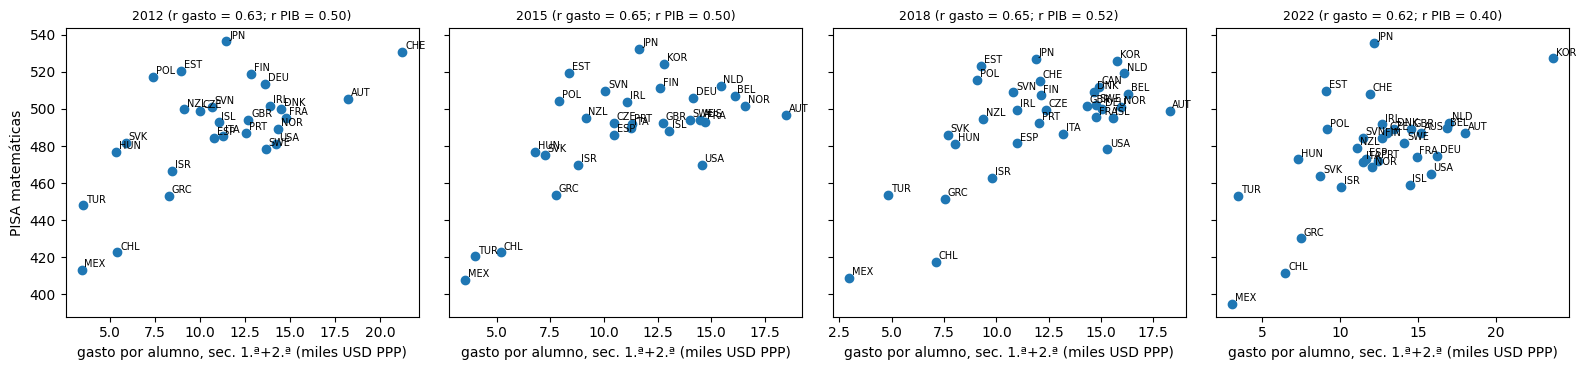

In [15]:
fig, ejes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
for ax, (edicion, g) in zip(ejes, economica.groupby('edicion')):
    g = g.dropna(subset=['pisa_math', 'gasto_alumno_2_3'])
    ax.scatter(g['gasto_alumno_2_3'] / 1000, g['pisa_math'])
    for _, f in g.iterrows():
        ax.annotate(f['pais'], (f['gasto_alumno_2_3'] / 1000, f['pisa_math']), fontsize=7, xytext=(2, 2), textcoords='offset points')
    r = g[['gasto_alumno_2_3', 'pisa_math']].corr().iloc[0, 1]
    r_pib = g[['pib_pc_ppp_const2021', 'pisa_math']].corr().iloc[0, 1]
    ax.set_title(f'{edicion} (r gasto = {r:.2f}; r PIB = {r_pib:.2f})', fontsize=9)
    ax.set_xlabel('gasto por alumno, sec. 1.ª+2.ª (miles USD PPP)')
ejes[0].set_ylabel('PISA matemáticas')
plt.tight_layout()
plt.show()

## 3. El problema: pocos países y poco cambio entre ediciones

La unidad de esta tabla es el **país-edición** (132 filas), pero las 4 ediciones de un mismo país se parecen mucho entre sí. Eso tiene consecuencias para cualquier modelo:

* **Las variables de presupuesto son del país y del año**: todos los alumnos y centros de un país en una edición comparten el mismo valor. Repetir ese valor en cientos de miles de filas de alumnos no añade información sobre su efecto.
* **Casi toda la variación es entre países, no dentro de un país a lo largo del tiempo.** Si cada país cambia poco entre 2012 y 2022, las 132 filas son en la práctica unas 33 observaciones casi repetidas: la **muestra efectiva** es mucho menor que 132.
* **Comparar países mezcla el efecto del presupuesto con todo lo demás que los distingue** (renta, cultura, sistema escolar). Y comparar un país consigo mismo en el tiempo (efectos fijos) casi no tiene variación con la que trabajar.

Aquí se mide cuánta variación es entre países y cuánta es entre ediciones, cuánto cambia cada variable por país y por edición, y cuál es la muestra efectiva.

### 3.1 Nivel de cada variable

| Nivel | Variables | Dónde están | Filas |
|---|---|---|---|
| **Alumno** | puntuación (`PV`), `ESCS`, sexo, inmigración, repetición de curso (`REPEAT`), ansiedad, autoeficacia e interés en matemáticas, pertenencia, minutos de aprendizaje, horas de estudio y deberes | tablas maestras de estudiantes | ~240.000-290.000 por edición |
| **Centro** | alumnos por profesor, tamaño de clase y de centro, profesorado certificado, escasez de recursos, tipo de centro (público, concertado, privado), financiación por origen, autonomía, ordenadores | tablas maestras de colegios | ~9.000-12.000 por edición |
| **Centro, calculado con los alumnos** | `ESCS` medio del centro (composición social), segregación | tablas maestras | ~9.000-12.000 por edición |
| **País-edición** | todo el presupuesto: gasto por alumno, % del PIB, composición del gasto, financiación, salarios, alumnos por docente agregados, PIB per cápita | OCDE, Banco Mundial, Eurostat | **132** |

Los alumnos y los centros **heredan** el valor de presupuesto de su país y edición: es una variable de contexto, no una medida propia.

### 3.2 ¿Cuánta variación es entre países y cuánta entre ediciones?

Para cada variable de la tabla se calcula:

* **% entre países**: parte de la varianza total que se debe a diferencias entre países (el resto es variación dentro de un país entre ediciones).
* **ICC** (correlación intraclase): lo parecidas que son las ediciones de un mismo país. Cerca de 1, las 4 ediciones son casi la misma observación.
* **Muestra efectiva** = filas / (1 + (ediciones por país − 1) × ICC): cuántas observaciones independientes equivalen realmente a las filas disponibles.
* **r 2015-2022**: correlación entre países de los valores de 2015 y de 2022. Cerca de 1, el orden de los países no cambia.
* **Cambio típico**: cambio medio absoluto entre ediciones consecutivas, medido en desviaciones típicas **entre países**. 0,3 significa que un país se mueve de media un tercio de lo que se separan los países entre sí.

In [16]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)


def descomposicion(df, variables):
    """Varianza entre países frente a entre ediciones, ICC, muestra efectiva y estabilidad de cada variable."""
    filas = []
    for v in variables:
        d = df[['pais', 'edicion', v]].dropna()
        d = d[d.groupby('pais')[v].transform('size') >= 2]      # países con al menos 2 ediciones
        k, n = d['pais'].nunique(), len(d)
        if k < 8 or n < 30:
            continue
        g = d.groupby('pais')[v]
        ss_tot = ((d[v] - d[v].mean()) ** 2).sum()
        ss_dentro = ((d[v] - g.transform('mean')) ** 2).sum()
        ni = g.size()
        n0 = (n - (ni ** 2).sum() / n) / (k - 1)             # tamaño medio de grupo ajustado (ANOVA desequilibrado)
        msb, msw = (ss_tot - ss_dentro) / (k - 1), ss_dentro / (n - k)
        icc = float(np.clip((msb - msw) / (msb + (n0 - 1) * msw), 0, 1))
        m = n / k
        w = d.pivot(index='pais', columns='edicion', values=v)
        sd_entre = w.mean(axis=1).std()
        cambios = [(w[b] - w[a]).abs().mean() / sd_entre for a, b in zip(w.columns[:-1], w.columns[1:])]
        r = w[[2015, 2022]].dropna().corr().iloc[0, 1] if {2015, 2022} <= set(w.columns) and w[[2015, 2022]].dropna().shape[0] >= 10 else np.nan
        filas.append({'variable': v, 'filas': n, 'países': k, '% entre países': 100 * (1 - ss_dentro / ss_tot), 'ICC': icc,
                      'muestra efectiva': n / (1 + (m - 1) * icc), 'r 2015-2022': r, 'cambio típico (DT entre países)': np.mean(cambios)})
    return pd.DataFrame(filas).set_index('variable')


excluidas = ('pais', 'edicion', 'pisa_n_alumnos', 'pisa_n_centros', 'poblacion', 'salario_real_indice_2015')   # índice base 2015: sin diferencias entre países por construcción
variables_tabla = [c for c in tabla.columns if c not in excluidas]
dec = descomposicion(tabla, variables_tabla)
dec['grupo'] = np.where(dec.index.isin(contexto.columns), 'contexto', np.where(dec.index.str.startswith('pisa_') & dec.index.isin(['pisa_math', 'pisa_read', 'pisa_scie']), 'resultado', 'económica'))
print(f'{len(dec)} variables. Medianas: % entre países = {dec["% entre países"].median():.0f}%, ICC = {dec["ICC"].median():.2f}, '
      f'muestra efectiva = {dec["muestra efectiva"].median():.0f} (de ~{dec["filas"].median():.0f} filas), r 2015-2022 = {dec["r 2015-2022"].median():.2f}')
dec.sort_values('ICC', ascending=False).round(2)

79 variables. Medianas: % entre países = 91%, ICC = 0.88, muestra efectiva = 34 (de ~100 filas), r 2015-2022 = 0.88


,filas,países,% entre países,ICC,muestra efectiva,r 2015-2022,cambio típico (DT entre países),grupo
variable,,,,,,,,
matricula_fte_2_3,121,31,99.84,1.00,31.05,1.00,0.02,económica
gasto_total_docentes_2_3,71,21,99.83,1.00,21.03,1.00,0.02,económica
gasto_total_personal_2_3,101,29,99.76,1.00,29.07,1.00,0.03,económica
gasto_total_corriente_2_3,105,29,99.65,1.00,29.10,1.00,0.04,económica
gasto_total_nodocentes_2_3,68,20,99.62,0.99,20.07,1.00,0.03,económica
salario_legal_15a_usd_ppp,107,29,99.09,0.99,29.26,0.99,0.09,económica
salario_legal_inicial_usd_ppp,90,30,99.02,0.99,30.29,0.98,0.10,económica
pisa_min_lengua,99,33,98.50,0.98,33.49,NaN,0.12,contexto
gasto_docentes_pct,67,20,97.50,0.97,20.49,0.97,0.17,económica


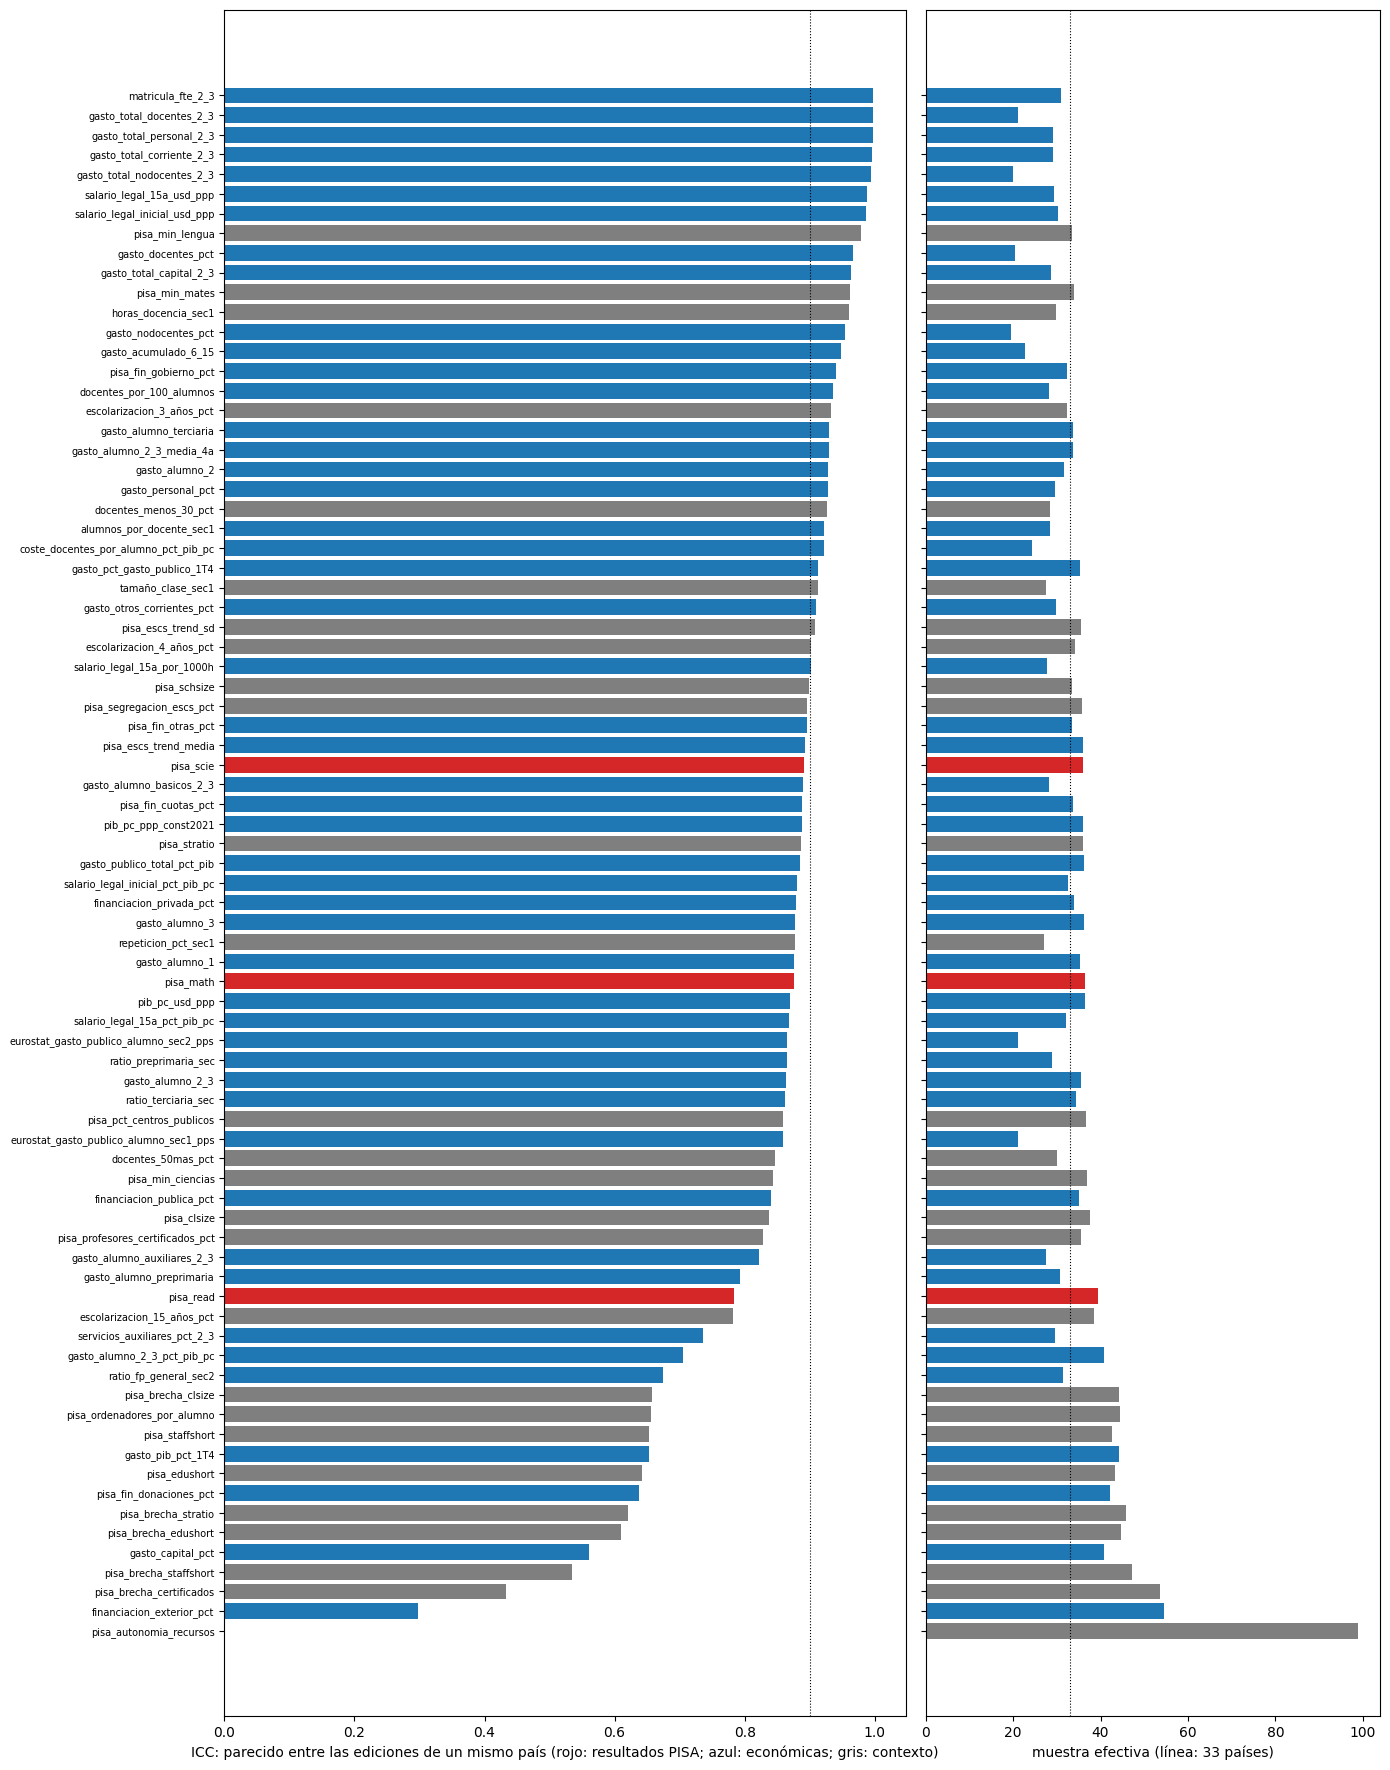

In [17]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 0.2 * len(dec) + 2), gridspec_kw={'width_ratios': [3, 2]})
orden = dec.sort_values('ICC')
colores = orden['grupo'].map({'resultado': 'tab:red', 'económica': 'tab:blue', 'contexto': 'tab:gray'})
ejes[0].barh(orden.index, orden['ICC'], color=colores)
ejes[0].axvline(0.9, color='black', ls=':', lw=0.8)
ejes[0].set_xlabel('ICC: parecido entre las ediciones de un mismo país (rojo: resultados PISA; azul: económicas; gris: contexto)')
ejes[0].tick_params(axis='y', labelsize=7)
ejes[1].barh(orden.index, orden['muestra efectiva'], color=colores)
ejes[1].axvline(33, color='black', ls=':', lw=0.8)
ejes[1].set_xlabel('muestra efectiva (línea: 33 países)')
ejes[1].set_yticklabels([])
plt.tight_layout()
plt.show()

### 3.3 Cómo cambia cada variable por país y por edición

Trayectorias de seis variables clave: cada línea gris es un país y la roja es España; la línea negra discontinua es la mediana de los 33. Si las líneas son casi horizontales y no se cruzan, hay poca variación en el tiempo con la que trabajar.

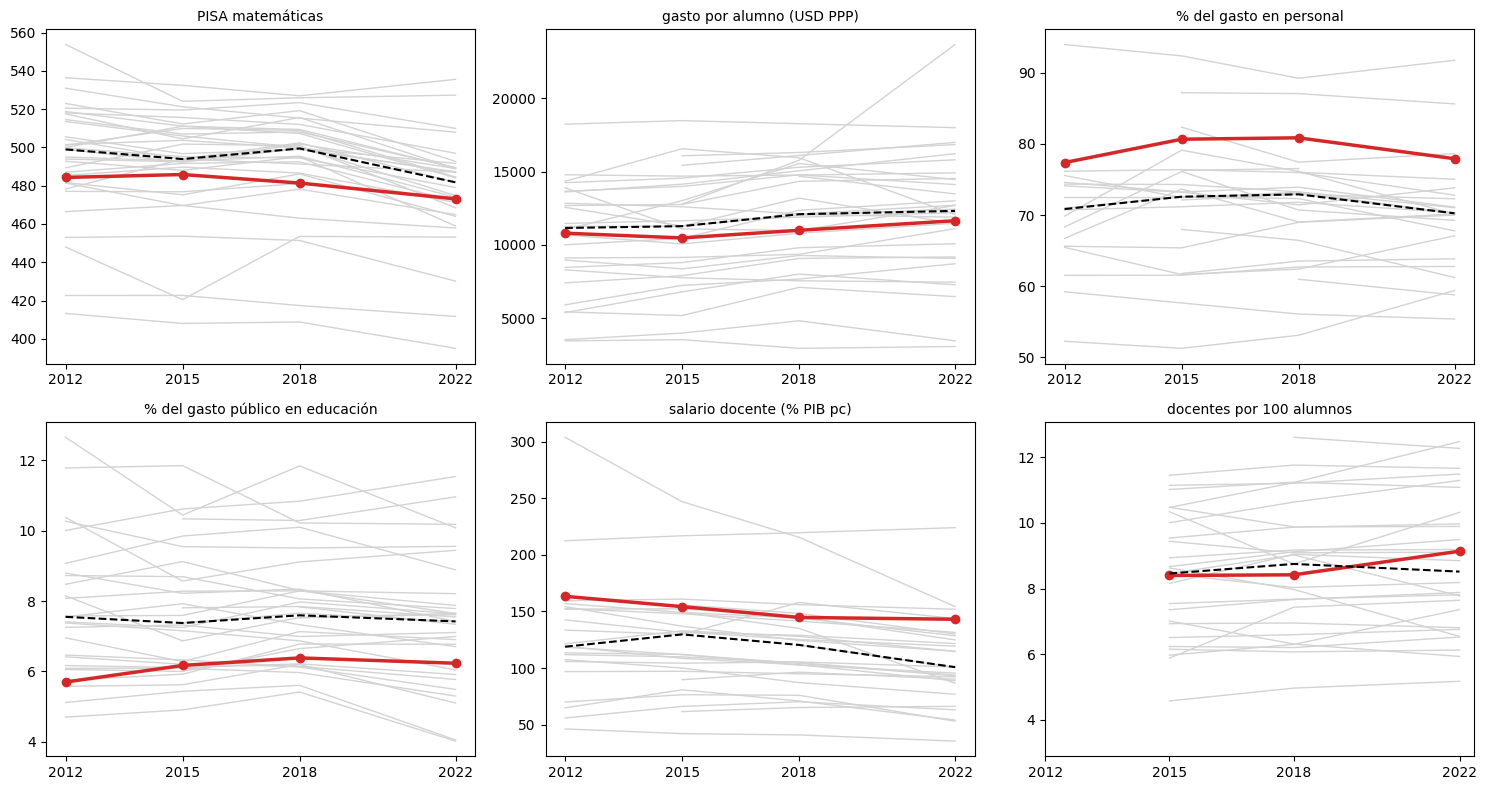

In [18]:
clave = {'pisa_math': 'PISA matemáticas', 'gasto_alumno_2_3': 'gasto por alumno (USD PPP)', 'gasto_personal_pct': '% del gasto en personal',
         'gasto_pct_gasto_publico_1T4': '% del gasto público en educación', 'salario_legal_15a_pct_pib_pc': 'salario docente (% PIB pc)',
         'docentes_por_100_alumnos': 'docentes por 100 alumnos'}
fig, ejes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (v, titulo) in zip(ejes.flat, clave.items()):
    w = tabla.pivot(index='edicion', columns='pais', values=v)
    ax.plot(w.index, w.drop(columns='ESP', errors='ignore'), color='lightgray', lw=1)
    ax.plot(w.index, w['ESP'], color='tab:red', lw=2.5, marker='o')
    ax.plot(w.index, w.median(axis=1), color='black', ls='--', lw=1.5)
    ax.set_title(titulo, fontsize=10)
    ax.set_xticks(EDICIONES)
plt.tight_layout()
plt.show()

### Cambio por país y por periodo

A la izquierda, el cambio porcentual del gasto por alumno entre ediciones; a la derecha, el cambio en puntos de matemáticas. Cada fila es un país. Los colores se centran en cero: el color débil indica poco cambio.

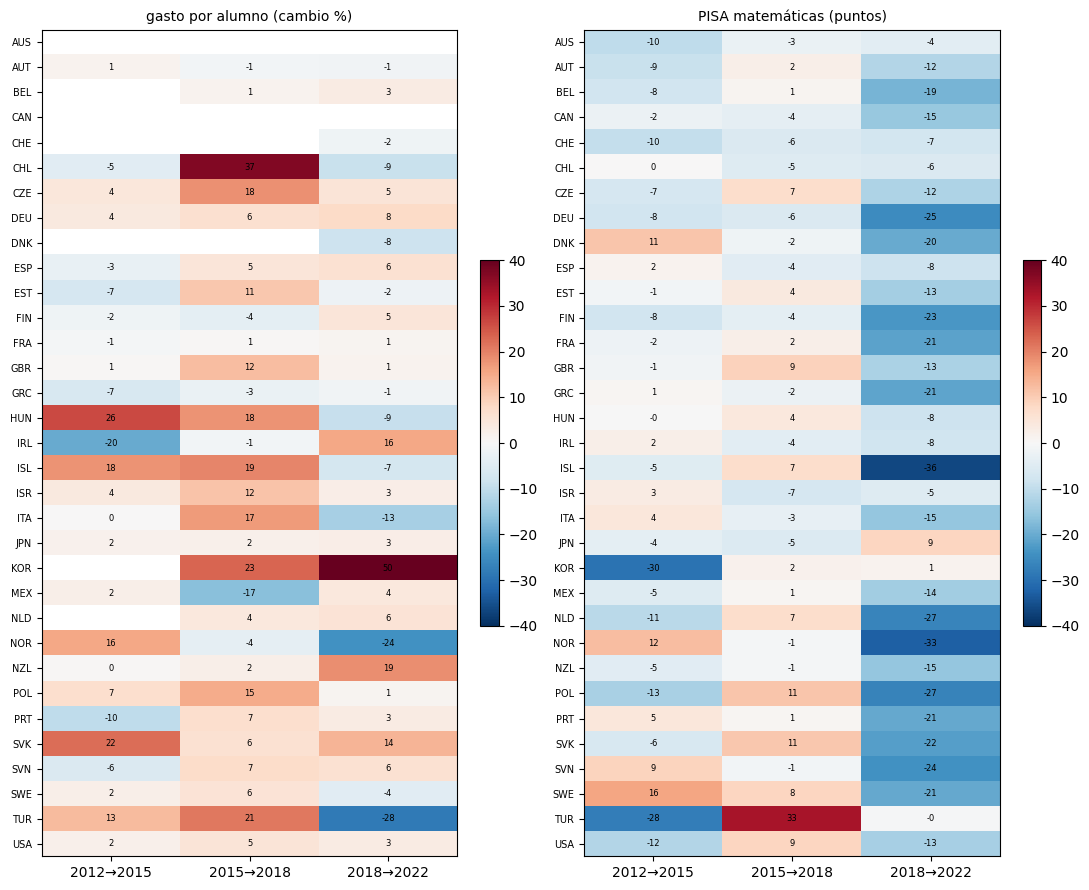

,gasto por alumno: |cambio| medio (%),"gasto por alumno: diferencia entre países (DT, %)",PISA mat.: |cambio| medio (puntos),"PISA mat.: diferencia entre países (DT, puntos)"
2012→2015,7.1,33.7,7.5,29.1
2015→2018,9.9,30.6,5.4,27.5
2018→2022,8.6,34.4,15.8,27.9


In [19]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 9))
periodos = [(2012, 2015), (2015, 2018), (2018, 2022)]
etiquetas = [f'{a}→{b}' for a, b in periodos]
for ax, (v, titulo, relativo, rango) in zip(ejes, [('gasto_alumno_2_3', 'gasto por alumno (cambio %)', True, 40),
                                                    ('pisa_math', 'PISA matemáticas (puntos)', False, 40)]):
    w = tabla.pivot(index='pais', columns='edicion', values=v)
    cam = pd.DataFrame({e: (100 * (w[b] / w[a] - 1) if relativo else w[b] - w[a]) for e, (a, b) in zip(etiquetas, periodos)})
    cam = cam.sort_index()
    im = ax.imshow(cam, cmap='RdBu_r', vmin=-rango, vmax=rango, aspect='auto')
    ax.set_xticks(range(len(etiquetas)))
    ax.set_xticklabels(etiquetas)
    ax.set_yticks(range(len(cam)))
    ax.set_yticklabels(cam.index, fontsize=7)
    for i in range(cam.shape[0]):
        for j in range(cam.shape[1]):
            if pd.notna(cam.iloc[i, j]):
                ax.text(j, i, f'{cam.iloc[i, j]:.0f}', ha='center', va='center', fontsize=6)
    ax.set_title(titulo, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()

resumen_cambios = pd.DataFrame({
    'gasto por alumno: |cambio| medio (%)': [(100 * (tabla.pivot(index='pais', columns='edicion', values='gasto_alumno_2_3')[b] / tabla.pivot(index='pais', columns='edicion', values='gasto_alumno_2_3')[a] - 1)).abs().mean() for a, b in periodos],
    'gasto por alumno: diferencia entre países (DT, %)': [100 * tabla[tabla['edicion'] == b]['gasto_alumno_2_3'].std() / tabla[tabla['edicion'] == b]['gasto_alumno_2_3'].mean() for a, b in periodos],
    'PISA mat.: |cambio| medio (puntos)': [(tabla.pivot(index='pais', columns='edicion', values='pisa_math')[b] - tabla.pivot(index='pais', columns='edicion', values='pisa_math')[a]).abs().mean() for a, b in periodos],
    'PISA mat.: diferencia entre países (DT, puntos)': [tabla[tabla['edicion'] == b]['pisa_math'].std() for a, b in periodos],
}, index=etiquetas)
resumen_cambios.round(1)

### Conclusión: qué significa esto para el modelo

* **Casi todo es diferencia entre países.** La mediana de las variables tiene un ICC de ~0,9 y una **muestra efectiva de ~35 observaciones** (de ~100 filas con dato): las 4 ediciones de un país aportan poco más que una. Los resultados PISA también (matemáticas: ICC 0,88).
* **El orden de los países casi no cambia** (r 2015-2022 mediana ≈ 0,9) y el gasto por alumno se mueve poco: un país cambia de media un 7-10 % entre ediciones, frente a una dispersión entre países del 30-34 %. Solo ~10 % de la varianza del gasto queda sin explicar tras quitar el país y la edición.
* **Lo que sí cambia entre ediciones es común a todos**: la caída de 2018 a 2022 (−13 puntos en matemáticas de mediana, mientras el gasto por alumno apenas varía). Eso lo absorbe un efecto de edición y no dice nada sobre el presupuesto.
* **España** está por debajo de la mediana en gasto (≈ 11.700 USD PPP frente a ≈ 12.300 en 2022) y en matemáticas (473 frente a 482), y su trayectoria es plana como la de casi todos.
* Las variables de **composición** del gasto, **capital**, **financiación exterior** y las **brechas entre centros** son las que más cambian (ICC < 0,65), pero también son las más ruidosas (`pisa_autonomia_recursos`, no comparable en 2018, ICC ≈ 0).

**Consecuencias**: (1) con la tabla país-edición solo se pueden hacer análisis descriptivos y de asociación entre países, no estimar el efecto de cambiar el presupuesto; (2) usar los 130.000-290.000 alumnos por edición para "aumentar la muestra" de una variable de país es pseudo-replicación; (3) para entrenar un modelo hay que apoyarse en **variables de alumno y centro**, que sí varían dentro de cada país, y tratar el presupuesto como contexto de país.

## 4. Cómo se gasta: composición y reparto

Dos países pueden gastar lo mismo por alumno y hacerlo de forma muy distinta. Se miran la **composición** del gasto de secundaria (docentes, personal no docente, otros gastos corrientes y capital) y el **reparto entre niveles** (cuánto se gasta en preprimaria y en terciaria respecto a secundaria). Último año con más datos: 2022.

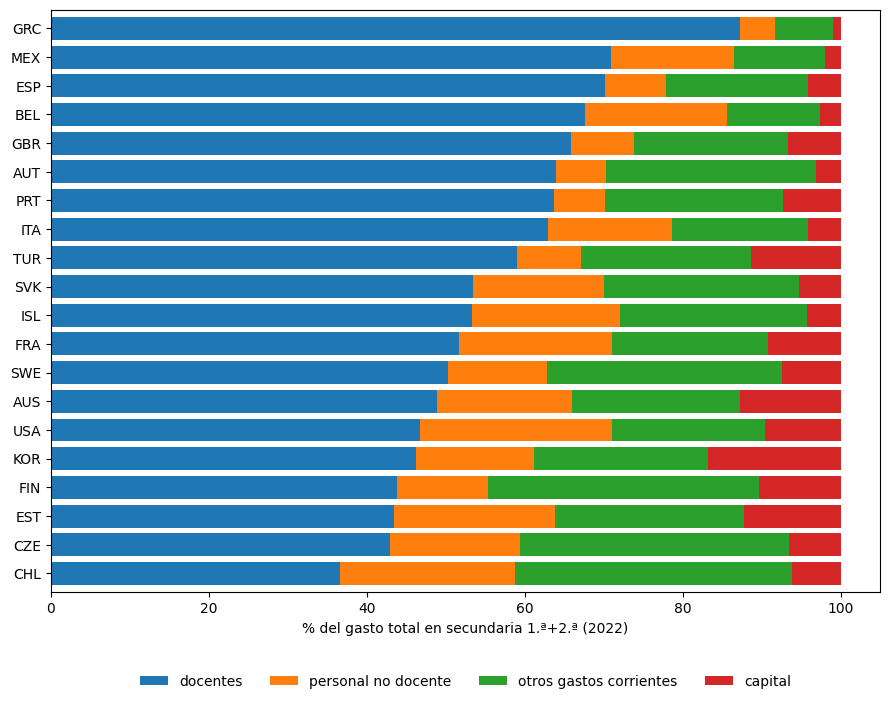

20 países con composición completa en 2022


In [20]:
comp = ['gasto_docentes_pct', 'gasto_nodocentes_pct', 'gasto_otros_corrientes_pct', 'gasto_capital_pct']
x = economica[economica['edicion'] == 2022].dropna(subset=comp).set_index('pais')[comp].sort_values('gasto_docentes_pct')
x.columns = ['docentes', 'personal no docente', 'otros gastos corrientes', 'capital']
ax = x.plot.barh(stacked=True, figsize=(9, 0.28 * len(x) + 1.5), width=0.8)
ax.set_xlabel('% del gasto total en secundaria 1.ª+2.ª (2022)')
ax.set_ylabel('')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
plt.tight_layout()
plt.show()
print(f'{len(x)} países con composición completa en 2022')

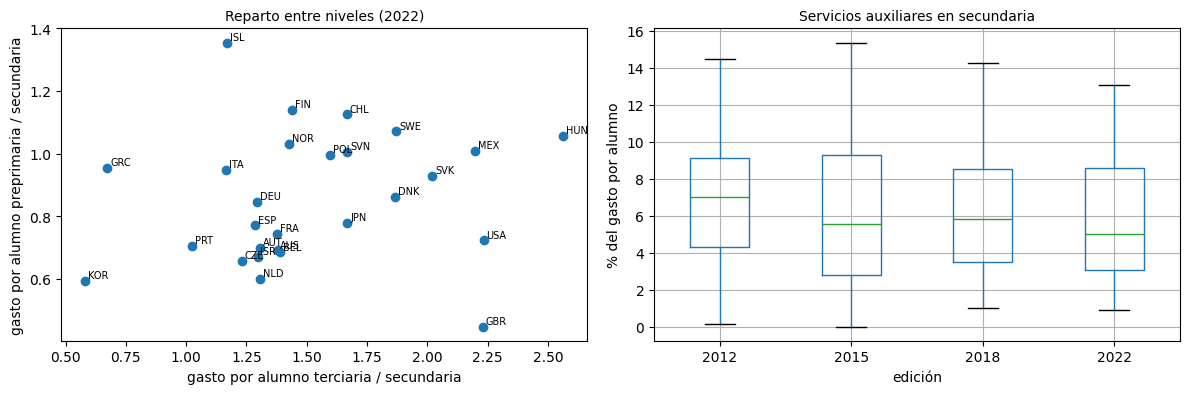

In [21]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.2))
g = economica[economica['edicion'] == 2022].dropna(subset=['ratio_terciaria_sec', 'ratio_preprimaria_sec'])
ejes[0].scatter(g['ratio_terciaria_sec'], g['ratio_preprimaria_sec'])
for _, f in g.iterrows():
    ejes[0].annotate(f['pais'], (f['ratio_terciaria_sec'], f['ratio_preprimaria_sec']), fontsize=7, xytext=(2, 2), textcoords='offset points')
ejes[0].set_xlabel('gasto por alumno terciaria / secundaria')
ejes[0].set_ylabel('gasto por alumno preprimaria / secundaria')
ejes[0].set_title('Reparto entre niveles (2022)', fontsize=10)

g = economica.dropna(subset=['servicios_auxiliares_pct_2_3'])
g.boxplot(column='servicios_auxiliares_pct_2_3', by='edicion', ax=ejes[1])
ejes[1].set_title('Servicios auxiliares en secundaria', fontsize=10)
ejes[1].set_xlabel('edición')
ejes[1].set_ylabel('% del gasto por alumno')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Las palancas del gasto por alumno

El gasto por alumno en personal docente se puede descomponer en **cuánto se paga a cada docente** (salario sobre el PIB per cápita) y **cuántos docentes hay por alumno** (precio × cantidad). Dos países con el mismo gasto pueden haber elegido pocos docentes bien pagados o muchos peor pagados. Solo hay alumnos por docente desde 2013, así que el análisis es de 2015 a 2022; se usa 2022 por tener más países.

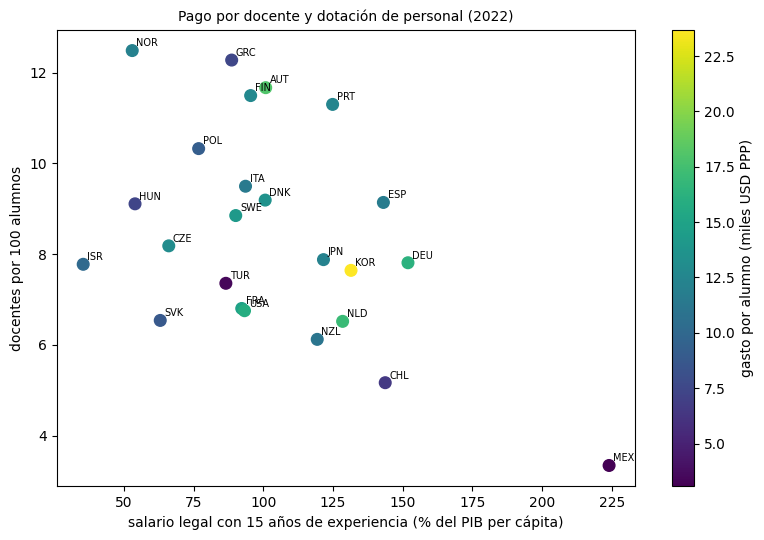

In [22]:
g = economica[economica['edicion'] == 2022].dropna(subset=['salario_legal_15a_pct_pib_pc', 'docentes_por_100_alumnos', 'gasto_alumno_2_3'])
fig, ax = plt.subplots(figsize=(8, 5.5))
puntos = ax.scatter(g['salario_legal_15a_pct_pib_pc'], g['docentes_por_100_alumnos'], c=g['gasto_alumno_2_3'] / 1000, s=70, cmap='viridis')
for _, f in g.iterrows():
    ax.annotate(f['pais'], (f['salario_legal_15a_pct_pib_pc'], f['docentes_por_100_alumnos']), fontsize=7, xytext=(3, 3), textcoords='offset points')
plt.colorbar(puntos, label='gasto por alumno (miles USD PPP)')
ax.set_xlabel('salario legal con 15 años de experiencia (% del PIB per cápita)')
ax.set_ylabel('docentes por 100 alumnos')
ax.set_title('Pago por docente y dotación de personal (2022)', fontsize=10)
plt.tight_layout()
plt.show()

### Parejas con el mismo gasto y palancas distintas

Parejas de país-edición con un gasto por alumno casi igual (diferencia inferior al 5%) y la mayor distancia en sus palancas (salario relativo y docentes por alumno, estandarizados).

In [23]:
p = economica.dropna(subset=['gasto_alumno_2_3', 'salario_legal_15a_pct_pib_pc', 'docentes_por_100_alumnos']).copy()
p['id'] = p['pais'] + ' ' + p['edicion'].astype(str)
z = p[['salario_legal_15a_pct_pib_pc', 'docentes_por_100_alumnos']]
z = (z - z.mean()) / z.std(ddof=0)
filas = []
for i in range(len(p)):
    for j in range(i + 1, len(p)):
        a, b = p.iloc[i], p.iloc[j]
        if a['pais'] != b['pais'] and abs(np.log(a['gasto_alumno_2_3'] / b['gasto_alumno_2_3'])) < 0.05:
            filas.append({'A': a['id'], 'B': b['id'],
                          'gasto A': a['gasto_alumno_2_3'], 'gasto B': b['gasto_alumno_2_3'],
                          'salario A (%PIBpc)': a['salario_legal_15a_pct_pib_pc'], 'salario B': b['salario_legal_15a_pct_pib_pc'],
                          'docentes/100 A': a['docentes_por_100_alumnos'], 'docentes/100 B': b['docentes_por_100_alumnos'],
                          'math A': a['pisa_math'], 'math B': b['pisa_math'],
                          'distancia': float(np.linalg.norm(z.iloc[i].to_numpy() - z.iloc[j].to_numpy()))})
parejas = pd.DataFrame(filas).sort_values('distancia', ascending=False).head(8)
parejas.round(1)

,A,B,gasto A,gasto B,salario A (%PIBpc),salario B,docentes/100 A,docentes/100 B,math A,math B,distancia
0,CHL 2018,GRC 2022,7107.0,7457.7,157.9,88.7,5.0,12.3,417.4,430.1,4.1
2,CHL 2018,HUN 2022,7107.0,7282.4,157.9,54.0,5.0,9.1,417.4,472.8,3.6
131,ISR 2022,SVN 2015,10082.9,10071.8,35.4,137.0,7.8,11.8,457.9,509.9,3.5
61,ESP 2015,ISR 2022,10481.6,10082.9,154.3,35.4,8.4,7.8,485.8,457.9,3.4
141,JPN 2015,NOR 2022,11654.7,12075.9,131.5,53.0,7.4,12.5,532.4,468.4,3.4
159,NLD 2015,NOR 2018,15439.5,15954.1,149.1,75.9,6.2,11.2,512.3,501.0,3.2
145,JPN 2018,NOR 2022,11899.0,12075.9,128.9,53.0,7.7,12.5,527.0,468.4,3.2
3,CHL 2018,SVK 2015,7107.0,7240.4,157.9,66.1,5.0,8.6,417.4,475.2,3.2


## 6. Variables económicas y rendimiento

Correlación con `pisa_math`, **dentro de cada edición** (las variables se estandarizan por edición para no mezclar escalas). Es solo exploratoria: casi todas están ligadas a la renta del país.

In [24]:
vars_econ = ['gasto_alumno_2_3', 'gasto_alumno_2_3_media_4a', 'gasto_acumulado_6_15', 'gasto_alumno_2_3_pct_pib_pc', 'gasto_pib_pct_1T4',
             'gasto_pct_gasto_publico_1T4', 'pib_pc_ppp_const2021', 'financiacion_publica_pct', 'financiacion_privada_pct', 'pisa_fin_gobierno_pct',
             'gasto_personal_pct', 'gasto_docentes_pct', 'gasto_nodocentes_pct', 'gasto_otros_corrientes_pct', 'gasto_capital_pct',
             'servicios_auxiliares_pct_2_3', 'ratio_preprimaria_sec', 'ratio_terciaria_sec', 'ratio_fp_general_sec2',
             'salario_legal_15a_pct_pib_pc', 'salario_real_indice_2015', 'docentes_por_100_alumnos', 'coste_docentes_por_alumno_pct_pib_pc']
z = economica[['edicion', 'pisa_math'] + vars_econ].copy()
z[['pisa_math'] + vars_econ] = z.groupby('edicion')[['pisa_math'] + vars_econ].transform(lambda s: (s - s.mean()) / s.std(ddof=0))
filas = {v: {'r con pisa_math': z[['pisa_math', v]].dropna().corr().iloc[0, 1], 'n': int(z[['pisa_math', v]].dropna().shape[0])} for v in vars_econ}
pd.DataFrame(filas).T.sort_values('r con pisa_math', key=abs, ascending=False).round(2)

,r con pisa_math,n
gasto_alumno_2_3,0.64,122.0
gasto_alumno_2_3_media_4a,0.62,104.0
gasto_acumulado_6_15,0.53,77.0
pib_pc_ppp_const2021,0.49,132.0
pisa_fin_gobierno_pct,0.45,118.0
gasto_alumno_2_3_pct_pib_pc,0.45,122.0
financiacion_publica_pct,0.44,119.0
financiacion_privada_pct,-0.44,118.0
ratio_preprimaria_sec,-0.39,100.0
docentes_por_100_alumnos,0.28,82.0


## 7. Eficiencia y perfiles de gasto

### 7.1 Rendimiento por encima o por debajo de lo esperado

Regresión de `pisa_math` sobre el log del gasto por alumno, el log del PIB per cápita, el `ESCS` medio y efectos de edición. El **residuo** es el rendimiento que no explican esas variables: positivo = rinde más de lo esperado. Es descriptivo, no causal, y con ~120 observaciones.

122 observaciones. Coeficientes:
const                    201.6
log_gasto                 40.6
log_pib                   -7.8
pisa_escs_trend_media     16.4
ed2015                    -3.2
ed2018                    -3.1
ed2022                   -20.4

(+0,1 en log del gasto = +10% de gasto por alumno)


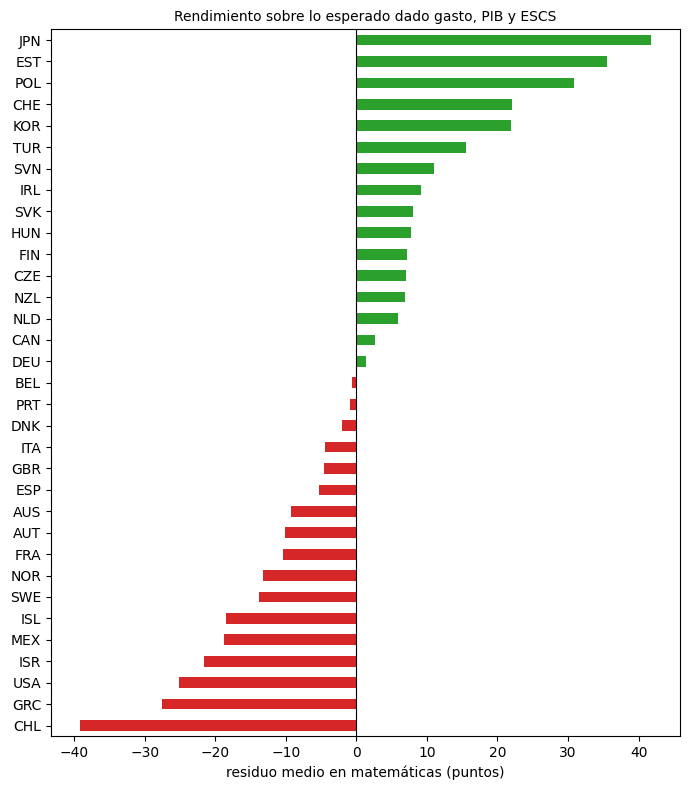

In [25]:
d = economica.assign(log_gasto=np.log(economica['gasto_alumno_2_3']), log_pib=np.log(economica['pib_pc_ppp_const2021']))
for e in (2015, 2018, 2022):
    d[f'ed{e}'] = (d['edicion'] == e).astype(float)
variables = ['log_gasto', 'log_pib', 'pisa_escs_trend_media', 'ed2015', 'ed2018', 'ed2022']
residuo, coef = residuo_ols(d, 'pisa_math', variables)
d['residuo_math'] = residuo
print(f'{len(residuo)} observaciones. Coeficientes:')
print(coef.round(1).to_string())
print('\n(+0,1 en log del gasto = +10% de gasto por alumno)')

medio = d.groupby('pais')['residuo_math'].agg(['mean', 'count']).dropna().sort_values('mean')
fig, ax = plt.subplots(figsize=(7, 8))
medio['mean'].plot.barh(ax=ax, color=['tab:red' if v < 0 else 'tab:green' for v in medio['mean']])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('residuo medio en matemáticas (puntos)')
ax.set_ylabel('')
ax.set_title('Rendimiento sobre lo esperado dado gasto, PIB y ESCS', fontsize=10)
plt.tight_layout()
plt.show()

### 7.2 Perfiles de gasto (K-means)

Agrupa país-ediciones por **cómo** gastan: esfuerzo (gasto por alumno sobre el PIB per cápita), % en personal, % en capital, salario docente relativo y % de financiación privada. Se estandarizan las variables y se elige el número de grupos por la silueta, exigiendo al menos 5 filas por grupo. Si la silueta es baja, los perfiles son una descripción y no grupos nítidos.

In [26]:
perfil_cols = ['gasto_alumno_2_3_pct_pib_pc', 'gasto_personal_pct', 'gasto_capital_pct',
               'salario_legal_15a_pct_pib_pc', 'financiacion_privada_pct']
etiquetas, siluetas = agrupar_perfiles(economica, perfil_cols)
print('Silueta por nº de grupos:', siluetas.round(2).to_dict())
x = economica.loc[etiquetas.index].assign(perfil=etiquetas)
resumen = x.groupby('perfil')[perfil_cols + ['gasto_alumno_2_3', 'pisa_math']].mean().round(1)
resumen['n'] = x.groupby('perfil').size()
resumen['países (más frecuentes)'] = x.groupby('perfil')['pais'].agg(lambda s: ', '.join(s.value_counts().index[:6]))
resumen

Silueta por nº de grupos: {2: 0.22, 3: 0.24, 4: 0.25, 5: 0.26, 6: 0.26}


,gasto_alumno_2_3_pct_pib_pc,gasto_personal_pct,gasto_capital_pct,salario_legal_15a_pct_pib_pc,financiacion_privada_pct,gasto_alumno_2_3,pisa_math,n,países (más frecuentes)
perfil,,,,,,,,,
0,23.0,66.4,7.5,77.5,6.8,11178.0,488.4,29,"FIN, SVK, NOR, POL, CZE, HUN"
1,18.6,66.5,9.0,148.3,22.7,5870.1,436.6,8,"TUR, CHL, AUS, MEX"
2,28.0,72.3,9.2,138.0,12.0,13887.2,502.7,31,"DEU, JPN, FRA, SVN, PRT, NLD"
3,26.0,79.8,2.9,113.9,7.0,11855.2,480.0,18,"AUT, ESP, GRC, ITA, DNK, HUN"


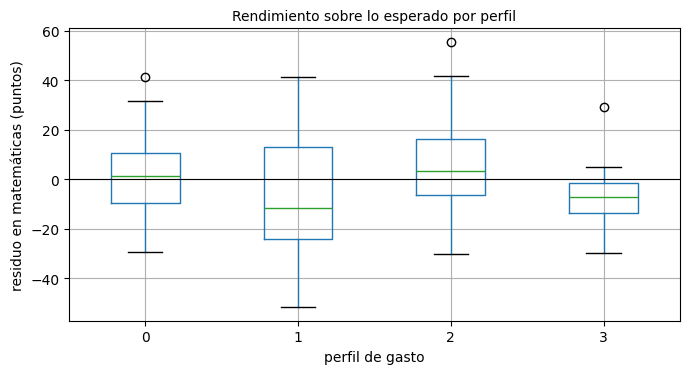

In [27]:
# Mismo nivel de gasto, ¿distinto rendimiento según el perfil? (residuo de matemáticas tras controlar PIB y ESCS)
x['residuo_math'] = d.loc[x.index, 'residuo_math']
fig, ax = plt.subplots(figsize=(7, 4))
x.boxplot(column='residuo_math', by='perfil', ax=ax)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('perfil de gasto')
ax.set_ylabel('residuo en matemáticas (puntos)')
ax.set_title('Rendimiento sobre lo esperado por perfil', fontsize=10)
plt.suptitle('')
plt.tight_layout()
plt.show()

## Hallazgos económicos

* **Composición** (pooled 2012-2022): el personal absorbe una mediana del 72% del gasto de secundaria (entre el 51% y el 94%), el capital un 7% y los servicios auxiliares un 6% (hasta el 15%). La composición casi no se relaciona con el rendimiento (|r| < 0,25).
* **Reparto por nivel**: la terciaria cuesta por alumno una mediana de 1,4 veces la secundaria y la preprimaria 0,8 veces; cuanto más se gasta en preprimaria y terciaria en relación con secundaria, menor rendimiento (r = −0,39 y −0,28), lo que probablemente refleja países con secundaria poco financiada.
* **Mismo gasto, palancas distintas**: Chile 2018 y Hungría 2022 gastan unos 7.100-7.300 USD PPP por alumno, pero Chile paga el 158% del PIB per cápita con 5 docentes por 100 alumnos y Hungría el 54% con 9; matemáticas 417 frente a 473. Israel 2022 y Eslovenia 2015 gastan lo mismo (~10.080): salario del 35% frente al 137% y 7,8 frente a 11,8 docentes por 100 alumnos; 458 frente a 510. Son países y años distintos, así que no es una comparación causal.
* **Correlación con matemáticas dentro de cada edición**: gasto por alumno 0,64 (media de los 4 últimos años 0,62; acumulado 6-15, 0,53), PIB per cápita 0,49, financiación pública 0,44 y privada −0,44. Más docentes por alumno, 0,28; salario relativo, −0,14.
* **Eficiencia**: controlando renta, `ESCS` y edición, +10% de gasto por alumno se asocia a unos +4 puntos en matemáticas (122 observaciones). Rinden por encima de lo esperado Japón (+42), Estonia (+35), Polonia (+31) y Suiza (+22), y por debajo Chile (−39), Grecia (−28), Estados Unidos (−25) e Israel (−22).
* **Perfiles de gasto**: 4 grupos con silueta baja (≈0,25), es decir, descriptivos y no nítidos: bajo gasto con salarios relativos altos y mucha financiación privada (Turquía, Chile, México; matemáticas 437), gasto medio con poco capital y mucho personal (Austria, España, Grecia, Italia; 480), gasto alto con personal y salarios altos (Alemania, Japón, Francia, Países Bajos; 503) y gasto medio con salarios bajos (Finlandia, Eslovaquia, Noruega, Polonia; 488).

**Cautelas**: son 132 observaciones, con más huecos en 2012; casi todas las variables dependen de la renta del país; los alumnos por docente no existen en 2012; y nada de esto es causal.

## Anexo · Contexto educativo (no económico)

Variables que **no son económicas** pero pueden servir de control o de mediador (cómo llegan los recursos, quién decide, cuánto se aprende). Son la tabla `contexto` (no se guarda en parquet), fuera del análisis principal. Se muestran su diccionario, su cobertura, la brecha de recursos entre centros y su relación con el rendimiento.

| Variable | Descripción | Unidad |
|---|---|---|
| `pisa_segregacion_escs_pct` | % de la varianza de `ESCS_TREND` que es **entre centros** (más alto = más segregación social) | % |
| `pisa_escs_trend_sd`, `pisa_n_centros`, `poblacion` | Desviación de `ESCS_TREND`, centros de la muestra y población | índice; nº; personas |
| `pisa_min_mates`, `pisa_min_lengua`, `pisa_min_ciencias` | Minutos semanales de aprendizaje por asignatura (solo 2012-2018) | minutos |
| `pisa_stratio`, `pisa_clsize`, `pisa_schsize` | Alumnos por profesor, tamaño de clase y de centro (PISA) | nº |
| `pisa_pct_centros_publicos` | % de centros públicos (`SCHLTYPE` = 3) entre los que tienen dato | % |
| `pisa_profesores_certificados_pct`, `pisa_profesores_master_pct` | Profesorado certificado y con máster o más (solo 2022) | % |
| `pisa_ordenadores_por_alumno` | Ordenadores disponibles por alumno (definición algo distinta en 2012) | ratio |
| `pisa_edushort`, `pisa_staffshort` | Escasez de material y de personal según la dirección (desde 2015) | índice |
| `pisa_autonomia_recursos` | Responsabilidad del centro sobre los recursos: índice oficial de cada edición (falta en 2018; **no comparable entre ediciones**) | índice |
| `pisa_brecha_stratio`, `_clsize`, `_certificados`, `_edushort`, `_staffshort` | **Brecha de recursos**: media del cuartil de centros más desfavorecido menos la del más favorecido (por `ESCS_TREND` medio del centro). Negativo en ratio, tamaño de clase y escasez = los desfavorecidos están mejor dotados; en certificados, al revés | unidades de la variable |
| `escolarizacion_3_años_pct`, `_4_`, `_15_` | % de la población de esa edad matriculada en cualquier nivel (desde 2013) | % |
| `repeticion_pct_sec1` | Repetidores en sec. 1.ª etapa (desde 2013) | % |
| `docentes_50mas_pct`, `docentes_menos_30_pct` | Profesorado de sec. 1.ª etapa con 50 o más años y con menos de 30 (desde 2013) | % |
| `tamaño_clase_sec1`, `horas_docencia_sec1` | Alumnos por clase (desde 2013) y horas anuales de docencia legales (no hay en 2022) | nº; horas |

In [28]:
contexto.drop(columns=['pais']).groupby('edicion').count().T

edicion,2012,2015,2018,2022
poblacion,33,33,33,33
pisa_n_centros,33,33,33,33
pisa_escs_trend_sd,33,33,33,33
pisa_segregacion_escs_pct,33,33,33,33
pisa_min_mates,33,33,33,0
pisa_min_lengua,33,33,33,0
pisa_min_ciencias,33,33,33,0
pisa_stratio,33,33,30,31
pisa_clsize,33,33,31,31
pisa_schsize,32,31,29,30


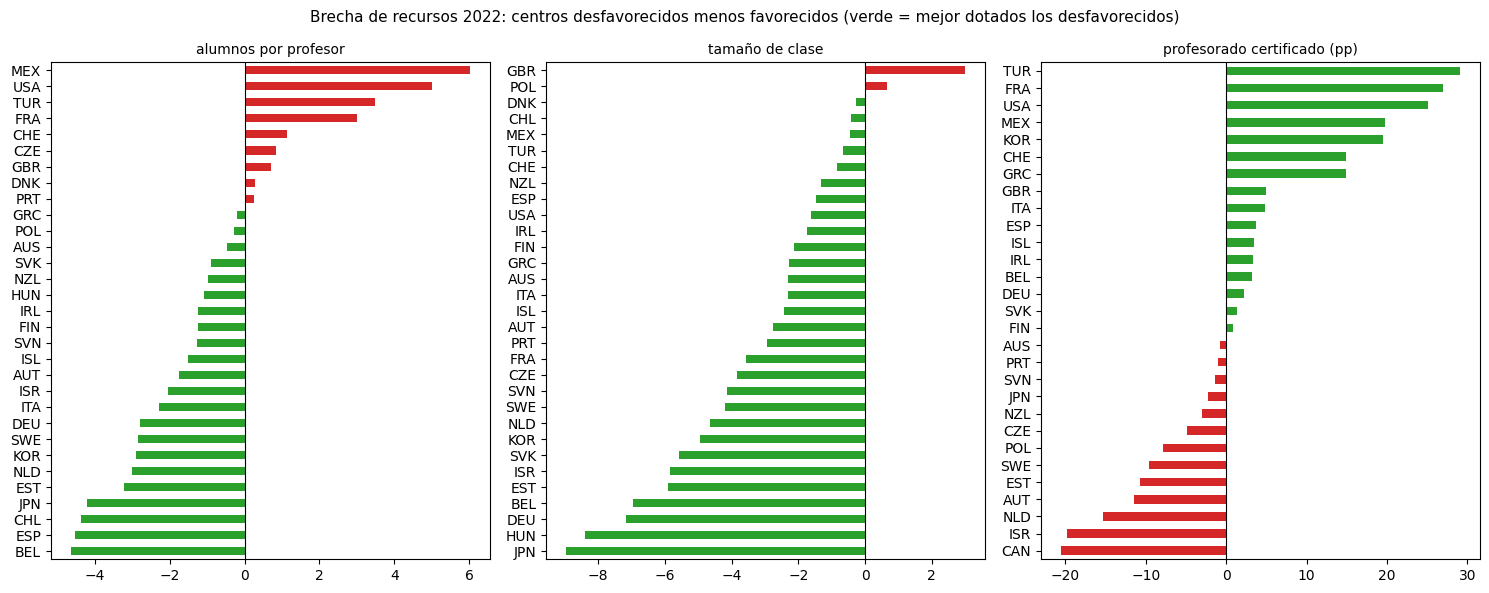

In [29]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 6), sharey=False)
for ax, (col, titulo) in zip(ejes, [('pisa_brecha_stratio', 'alumnos por profesor'), ('pisa_brecha_clsize', 'tamaño de clase'),
                                     ('pisa_brecha_certificados', 'profesorado certificado (pp)')]):
    g = contexto[contexto['edicion'] == 2022].dropna(subset=[col]).set_index('pais')[col].sort_values()
    g.plot.barh(ax=ax, color=['tab:green' if v < 0 else 'tab:red' for v in g] if col != 'pisa_brecha_certificados'
                else ['tab:red' if v < 0 else 'tab:green' for v in g])
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel('')
plt.suptitle('Brecha de recursos 2022: centros desfavorecidos menos favorecidos (verde = mejor dotados los desfavorecidos)', fontsize=11)
plt.tight_layout()
plt.show()

In [30]:
ctx = [c for c in contexto.columns if c not in ('pais', 'edicion', 'pisa_n_centros', 'poblacion')]
z = contexto.merge(economica[['pais', 'edicion', 'pisa_math']], on=['pais', 'edicion'])[['edicion', 'pisa_math'] + ctx]
z[['pisa_math'] + ctx] = z.groupby('edicion')[['pisa_math'] + ctx].transform(lambda s: (s - s.mean()) / s.std(ddof=0))
filas = {v: {'r con pisa_math': z[['pisa_math', v]].dropna().corr().iloc[0, 1], 'n': int(z[['pisa_math', v]].dropna().shape[0])} for v in ctx}
pd.DataFrame(filas).T.sort_values('r con pisa_math', key=abs, ascending=False).round(2)

,r con pisa_math,n
pisa_escs_trend_sd,-0.70,132.0
pisa_segregacion_escs_pct,-0.57,132.0
pisa_brecha_edushort,-0.55,99.0
pisa_profesores_certificados_pct,0.55,122.0
pisa_brecha_stratio,-0.47,127.0
escolarizacion_15_años_pct,0.47,98.0
horas_docencia_sec1,-0.46,85.0
pisa_stratio,-0.45,127.0
pisa_brecha_staffshort,-0.41,93.0
escolarizacion_3_años_pct,0.37,93.0


### Hallazgos del contexto educativo

* **Segregación social entre centros**: r = −0,57 con matemáticas (dentro de cada edición); la desigualdad de `ESCS` dentro del país (desviación), −0,70.
* **Profesorado certificado** (0,55) y **brecha de alumnos por profesor** entre centros desfavorecidos y favorecidos (−0,47) son las otras asociaciones fuertes. Autonomía sobre recursos (0,06) y edad del profesorado (|r| < 0,15) casi no se relacionan.
* **Equidad de recursos**: en la mayoría de los países los centros desfavorecidos tienen menos alumnos por profesor y clases más pequeñas (puede reflejar centros rurales pequeños, no solo compensación); lo contrario ocurre en México, Estados Unidos, Turquía y Francia (alumnos por profesor). Faltan docentes certificados en los centros desfavorecidos de Canadá, Israel, Países Bajos y Austria (−11 a −20 puntos porcentuales).
* **Escolarización**: a los 15 años (0,47) y a los 3 (0,37) se asocia con rendimiento; los minutos semanales de matemáticas, negativamente (−0,36): más horas no implican más puntos entre países.

**Cautelas**: la autonomía no existe en 2018 ni es comparable entre ediciones; el tiempo de aprendizaje no existe en 2022; casi todo depende de la renta del país.